# Quantum many-body spin systems — the textbook (dense-matrix) way

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 2 — Quantum many-body spin systems: the textbook way*

## 1. Introduction and motivation

A single spin-1/2 is the simplest quantum system there is: two basis states, three Pauli matrices, and
everything can be solved with pen and paper. A **quantum many-body spin system** is what you get when you put
$N$ such spins next to each other and let them *interact*. Nothing new is added to the rules of quantum
mechanics, and yet the result is one of the richest subjects of modern physics:

* **Magnetism.** The electrons localised on the ions of an insulating crystal carry spins that are coupled
  to their neighbours by the exchange interaction. Ferromagnets, antiferromagnets and the still mysterious
  quantum spin liquids are all collective states of many interacting spins. The quasi-one-dimensional magnet
  CoNb$_2$O$_6$, for instance, is an almost ideal realisation of the *transverse-field Ising chain* that we
  will diagonalise below.
* **Quantum simulators.** Chains and arrays of trapped ions, neutral atoms excited to Rydberg states,
  ultracold atoms in optical lattices and superconducting circuits all realise, to an excellent approximation,
  spin-1/2 Hamiltonians whose couplings the experimentalist can *program*. Experiments with 50–250 spins exist
  today (Bernien *et al.* 2017: 51 Rydberg atoms; Zhang *et al.* 2017: 53 trapped ions; Ebadi *et al.* 2021:
  256 Rydberg atoms — all in the references).
* **Quantum computers.** A qubit *is* a spin-1/2. A quantum processor with $N$ qubits is an interacting spin
  system whose Hamiltonian is switched on and off in time. Everything you learn here about $N$ spins is, word
  for word, the mathematics of $N$ qubits.
* **Quantum phase transitions.** The ground state of a many-body system can change its character abruptly when a
  parameter of the Hamiltonian (a magnetic field, say) is tuned through a critical value. Such transitions
  are a central theme of condensed-matter physics.

The catch is the size of the problem. One spin needs 2 complex numbers, two spins need 4, and $N$ spins need
$2^N$. This exponential growth is the reason why classical computers struggle with quantum matter, why
Feynman proposed quantum simulators in the first place, and why this course exists: **we want to push a
classical computer as far as it can go, and understand exactly where and why it stops.**

**This notebook is the physics entry point of the course.** We deliberately use the most direct method, the
one found in every textbook: write every operator as a $2^N\times 2^N$ matrix (with Kronecker products), add
the matrices up to get the Hamiltonian, and hand it to a dense eigenvalue solver. This is called **exact
diagonalisation (ED)**. There are no tricks here; the goal is to understand the objects. At the end we will
*measure* how quickly this approach hits the exponential wall, and that will motivate the matrix-free
methods of the rest of the course.

### Road map

1. **One spin-1/2** (Section 2): states, Pauli matrices, the Bloch sphere, expectation values, the Born rule.
2. **Two spins** (Section 3): the tensor product and the Kronecker product, by hand and with `jnp.kron`;
   product states versus entangled states (the singlet); operators $A\otimes 1$ and $1\otimes B$; our first
   interacting Hamiltonian.
3. **$N$ spins** (Section 4): the $2^N$-dimensional Hilbert space, labelling basis states by bit strings, the
   flat-index convention used in the whole course, site operators $\sigma_j^\alpha$ as a chain of Kronecker
   products (`site_operator`), the total magnetisation.
4. **Model Hamiltonians** (Section 5): transverse-field Ising model (TFIM), Heisenberg and XXZ chains, and the
   physical systems they describe.
5. **Building the Hamiltonian matrix** (Section 6): `build_hamiltonian_dense`, Hermiticity, symmetries and the
   block structure they imply.
6. **Exact diagonalisation** (Section 7): spectrum, the energy gap of the TFIM as a function of the field and
   the finite-size precursor of the quantum critical point at $h=J$, order parameters, ground-state
   correlations, the Heisenberg antiferromagnet.
7. **The exponential wall** (Section 8): measured run times and memory, sparse matrices as the traditional
   remedy, and an announcement of the matrix-free remedy that this course is about.

### What you will learn

*Physics*

* what the Hilbert space of $N$ spins looks like and what "entangled" means;
* what the transverse-field Ising and Heisenberg/XXZ Hamiltonians describe and where they are realised;
* what an energy gap, an order parameter and a correlation function are, and how a quantum phase transition
  shows up in a finite system;
* how symmetries (magnetisation conservation, spin-flip parity) organise the spectrum.

*Numerical methods*

* the Kronecker product and how it turns single-spin operators into many-body matrices;
* exact diagonalisation with a dense Hermitian eigensolver and how to check its output;
* cost accounting: memory $O(4^N)$ and time $O(8^N)$ of the dense approach, versus $O(N2^N)$ memory for
  sparse matrices and $O(2^N)$ for a single state vector.

*Implementation practice*

* small pure functions with documented conventions, validated against analytic results at every step;
* index conventions (which spin is the most significant bit) — the classic source of silent bugs;
* honest timing of JAX code (`block_until_ready`, compile time versus run time), and `jax.jit` + `jax.vmap`
  to run a parameter sweep as a single compiled program.

### Prerequisites

One semester of quantum mechanics (spin-1/2, Pauli matrices, eigenvalues and eigenvectors) and the two
previous notebooks: [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) (arrays, `jit`, `vmap`, timing) and
[02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb) (index notation, `reshape` and C-ordering). We use
`jax.numpy` (imported as `jnp`) for all arrays, but nothing more advanced than matrix products and `kron`.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. One spin-1/2

### 2.1 States and Pauli matrices

The state of a spin-1/2 is a normalised vector in the two-dimensional complex vector space
$\mathbb{C}^2$. We choose once and for all the basis of eigenstates of the $z$ component of the spin and
write

$$ |{\uparrow}\rangle \equiv |0\rangle = \begin{pmatrix}1\\0\end{pmatrix},\qquad
   |{\downarrow}\rangle \equiv |1\rangle = \begin{pmatrix}0\\1\end{pmatrix},\qquad
   |\psi\rangle = a\,|0\rangle + b\,|1\rangle,\quad |a|^2+|b|^2=1 . $$

The labels $0$ and $1$ are the quantum-information names of "up" and "down"; we will use both. The spin
operator is $\hat{\mathbf S} = \frac{\hbar}{2}\boldsymbol\sigma$ with the three **Pauli matrices**

$$ X \equiv \sigma^x = \begin{pmatrix}0&1\\1&0\end{pmatrix},\qquad
   Y \equiv \sigma^y = \begin{pmatrix}0&-i\\i&0\end{pmatrix},\qquad
   Z \equiv \sigma^z = \begin{pmatrix}1&0\\0&-1\end{pmatrix}. $$

> **Convention of the whole course.** $|0\rangle=(1,0)^T$ is the $+1$ eigenstate of $Z$ ("spin up"),
> $|1\rangle=(0,1)^T$ the $-1$ eigenstate ("spin down"). We work with Pauli matrices (eigenvalues $\pm1$),
> *not* with spin operators $S^\alpha=\sigma^\alpha/2$, and we set $\hbar=1$. When you compare with a paper
> written in terms of $S^\alpha$, couplings differ by factors of 4 (two-spin terms) and 2 (field terms).

The Pauli matrices have three properties that we will use again and again:

1. they are **Hermitian** ($\sigma^\dagger=\sigma$, so they are observables) and **square to the identity**
   ($\sigma^2=1$, so their eigenvalues are $\pm1$);
2. different Pauli matrices **anticommute**: $XY=-YX$, etc.;
3. their commutators close: $[X,Y]=2iZ$ and cyclic permutations (this is the angular-momentum algebra
   $[S^x,S^y]=iS^z$ in disguise).

Together with the identity they form a basis of all $2\times2$ matrices. Let us define them and let the
computer confirm the algebra. We also define a tiny helper `checkpoint` that prints an error and asserts that
it is below the tolerance `TOL` of the configuration cell — we will use it for every test in this notebook.

In [2]:
# ==============================================================================
# STEP 1: the single-spin building blocks
# ==============================================================================
# CDTYPE (complex128 by default) comes from the Configuration cell above.
I2 = jnp.eye(2, dtype=CDTYPE)                                   # identity
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)                   # sigma^x : flips the spin
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)                # sigma^y : flips the spin with phases -+i
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)                  # sigma^z : +1 for up, -1 for down

up = jnp.array([1, 0], dtype=CDTYPE)                            # |0> = |up>   : Z|0> = +|0>
down = jnp.array([0, 1], dtype=CDTYPE)                          # |1> = |down> : Z|1> = -|1>


def checkpoint(label, err, tol=TOL):
    """Print a validation error and stop the notebook if it is not below the tolerance.

    Every numerical claim in these notes is backed by such a check against an independent reference.
    """
    err = float(err)
    print(f"  [{'ok' if err < tol else 'FAIL'}] {label:<58s} error = {err:.2e}")
    assert err < tol, f"checkpoint failed: {label}"


def commutator(A, B):
    """[A, B] = AB - BA."""
    return A @ B - B @ A


print("Checkpoint: Pauli algebra")
for name, P in (("X", X), ("Y", Y), ("Z", Z)):
    checkpoint(f"{name} is Hermitian", jnp.abs(P - P.conj().T).max())
    checkpoint(f"{name}^2 = 1", jnp.abs(P @ P - I2).max())
checkpoint("XY + YX = 0   (anticommutation)", jnp.abs(X @ Y + Y @ X).max())
checkpoint("[X, Y] = 2iZ", jnp.abs(commutator(X, Y) - 2j * Z).max())
checkpoint("[Y, Z] = 2iX", jnp.abs(commutator(Y, Z) - 2j * X).max())
checkpoint("[Z, X] = 2iY", jnp.abs(commutator(Z, X) - 2j * Y).max())
checkpoint("Z|0> = +|0>  and  Z|1> = -|1>", jnp.abs(Z @ up - up).max() + jnp.abs(Z @ down + down).max())
checkpoint("X|0> = |1>   (X flips the spin)", jnp.abs(X @ up - down).max())

Checkpoint: Pauli algebra


  [ok] X is Hermitian                                             error = 0.00e+00
  [ok] X^2 = 1                                                    error = 0.00e+00
  [ok] Y is Hermitian                                             error = 0.00e+00
  [ok] Y^2 = 1                                                    error = 0.00e+00
  [ok] Z is Hermitian                                             error = 0.00e+00
  [ok] Z^2 = 1                                                    error = 0.00e+00
  [ok] XY + YX = 0   (anticommutation)                            error = 0.00e+00
  [ok] [X, Y] = 2iZ                                               error = 0.00e+00
  [ok] [Y, Z] = 2iX                                               error = 0.00e+00
  [ok] [Z, X] = 2iY                                               error = 0.00e+00


  [ok] Z|0> = +|0>  and  Z|1> = -|1>                              error = 0.00e+00
  [ok] X|0> = |1>   (X flips the spin)                            error = 0.00e+00


All identities hold to machine precision. $X$ *flips* the spin,
$X|0\rangle=|1\rangle$, $X|1\rangle=|0\rangle$. In a many-body Hamiltonian a term $X_j$ will therefore
connect basis states that differ by one flipped spin — remember this when we look at the matrix structure in
Section 4.

### 2.2 The Bloch sphere

A normalised state has two complex amplitudes, i.e. four real numbers, minus one for the normalisation and
minus one for the global phase (which has no physical meaning). Two real parameters remain, and they can be
chosen as angles on a sphere:

$$ |\psi(\theta,\varphi)\rangle = \cos\frac{\theta}{2}\,|0\rangle + e^{i\varphi}\sin\frac{\theta}{2}\,|1\rangle,
   \qquad 0\le\theta\le\pi,\; 0\le\varphi<2\pi . $$

The **expectation value** of an observable $O$ in the state $|\psi\rangle$ is
$\langle O\rangle = \langle\psi|O|\psi\rangle = \sum_{ab}\psi_a^*\,O_{ab}\,\psi_b$. For the three Pauli
matrices a two-line calculation gives (worth doing once by hand)

$$ \langle X\rangle = 2\,\mathrm{Re}(a^*b) = \sin\theta\cos\varphi,\qquad
   \langle Y\rangle = 2\,\mathrm{Im}(a^*b) = \sin\theta\sin\varphi,\qquad
   \langle Z\rangle = |a|^2-|b|^2 = \cos\theta , $$

with $a=\cos\frac\theta2$, $b=e^{i\varphi}\sin\frac\theta2$. The vector
$\mathbf r=(\langle X\rangle,\langle Y\rangle,\langle Z\rangle)$ is the **Bloch vector**; for a pure state it
is the unit vector with polar angle $\theta$ and azimuth $\varphi$. The north pole is $|0\rangle$ (spin up),
the south pole $|1\rangle$, and the points on the equator are equal-weight superpositions such as
$|{+}\rangle=(|0\rangle+|1\rangle)/\sqrt2$, the $+1$ eigenstate of $X$. *The state of one spin-1/2 is fully
described by the direction in which it points* — a classical-looking picture that, as we will see, fails
completely for two spins.

**From formula to code.** `bloch_state` is the formula above; `expval` computes $\psi^\dagger(O\psi)$ with
`jnp.vdot`, which complex-conjugates its first argument. To evaluate the Bloch vector for many angles at once
we do not write a loop: `jax.vmap` turns the function written for one $\theta$ into a function for a whole
array of $\theta$'s (see [notebook 01](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)).

Checkpoint: Bloch vector


  [ok] (<X>,<Y>,<Z>) = (sin t cos p, sin t sin p, cos t)          error = 1.94e-16


  [ok] |r| = 1 for every pure state                               error = 2.22e-16


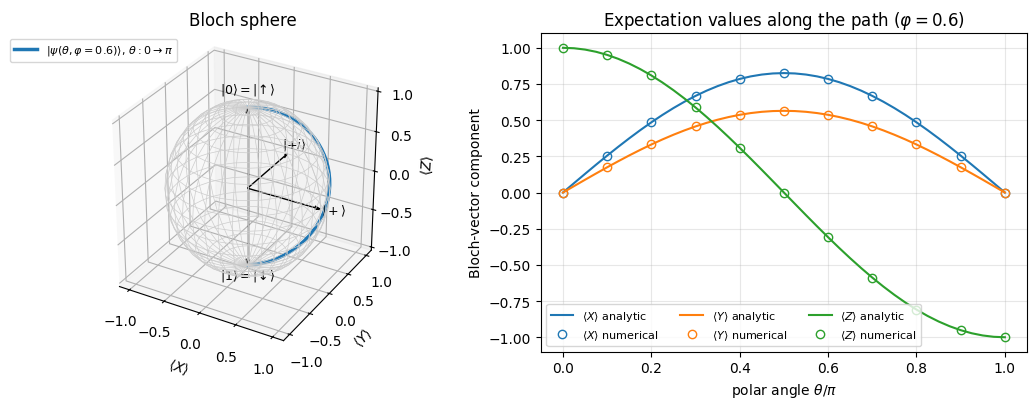

In [3]:
# ==============================================================================
# STEP 2: states on the Bloch sphere and expectation values
# ==============================================================================
def bloch_state(theta, phi):
    """Spin-1/2 state pointing along the direction (theta, phi).

    MATH   |psi> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>
    """
    return jnp.array([jnp.cos(theta / 2), jnp.exp(1j * phi) * jnp.sin(theta / 2)], dtype=CDTYPE)


def expval(psi, O):
    """Expectation value <psi|O|psi> of a Hermitian matrix O in the (normalised) state vector psi.

    MATH   <O> = sum_{ab} psi_a^* O_ab psi_b = psi^dagger (O psi)      (real because O is Hermitian)
    COST   one matrix-vector product: O(d^2) for a dense d x d matrix.
    """
    return jnp.real(jnp.vdot(psi, O @ psi))


def bloch_vector(psi):
    """Bloch vector (<X>, <Y>, <Z>) of a single-spin state."""
    return jnp.stack([expval(psi, X), expval(psi, Y), expval(psi, Z)])


# --- checkpoint: the numerical Bloch vector equals the analytic unit vector ------------------------
phi0 = 0.6
thetas = jnp.linspace(0.0, jnp.pi, 41)
r_num = jax.vmap(lambda th: bloch_vector(bloch_state(th, phi0)))(thetas)          # shape (41, 3)
r_exact = jnp.stack([jnp.sin(thetas) * jnp.cos(phi0), jnp.sin(thetas) * jnp.sin(phi0), jnp.cos(thetas)], axis=1)
print("Checkpoint: Bloch vector")
checkpoint("(<X>,<Y>,<Z>) = (sin t cos p, sin t sin p, cos t)", jnp.abs(r_num - r_exact).max())
checkpoint("|r| = 1 for every pure state", jnp.abs(jnp.linalg.norm(r_num, axis=1) - 1).max())

# --- figure: the path on the sphere and the three components ---------------------------------------
fig = plt.figure(figsize=(11, 4.2))
ax = fig.add_subplot(1, 2, 1, projection="3d")
u, v = np.meshgrid(np.linspace(0, 2 * np.pi, 37), np.linspace(0, np.pi, 19))
ax.plot_wireframe(np.cos(u) * np.sin(v), np.sin(u) * np.sin(v), np.cos(v), color="0.8", linewidth=0.5)
ax.plot(*np.asarray(r_num).T, color="C0", lw=2.5, label=rf"$|\psi(\theta,\varphi={phi0})\rangle$, $\theta:0\to\pi$")
for vec, lab in (((0, 0, 1), r"$|0\rangle=|\!\uparrow\rangle$"), ((0, 0, -1), r"$|1\rangle=|\!\downarrow\rangle$"),
                 ((1, 0, 0), r"$|+\rangle$"), ((0, 1, 0), r"$|{+}i\rangle$")):
    ax.quiver(0, 0, 0, *vec, color="k", arrow_length_ratio=0.08, linewidth=1)
    ax.text(*(1.18 * np.array(vec)), lab, ha="center", fontsize=9)
ax.set_xlabel(r"$\langle X\rangle$"); ax.set_ylabel(r"$\langle Y\rangle$"); ax.set_zlabel(r"$\langle Z\rangle$")
ax.set_title("Bloch sphere"); ax.set_box_aspect((1, 1, 1)); ax.legend(loc="upper left", bbox_to_anchor=(-0.25, 1.0), fontsize=8)
ax2 = fig.add_subplot(1, 2, 2)
for k, (lab, col) in enumerate(((r"$\langle X\rangle$", "C0"), (r"$\langle Y\rangle$", "C1"), (r"$\langle Z\rangle$", "C2"))):
    ax2.plot(thetas / np.pi, r_exact[:, k], color=col, label=lab + " analytic")
    ax2.plot(thetas[::4] / np.pi, r_num[::4, k], "o", color=col, mfc="none", label=lab + " numerical")
ax2.set_xlabel(r"polar angle $\theta/\pi$"); ax2.set_ylabel("Bloch-vector component")
ax2.set_title(rf"Expectation values along the path ($\varphi={phi0}$)"); ax2.grid(alpha=0.3); ax2.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

The blue path runs from the north pole ($\theta=0$, spin up) to the south pole along the meridian
$\varphi=0.6$; the circles (numerical $\langle\psi|\sigma^\alpha|\psi\rangle$) sit on the analytic curves.

### 2.3 Measurement: the Born rule

Expectation values are averages over many measurements. A *single* measurement of the spin along a unit
vector $\mathbf n$ (the observable $\mathbf n\cdot\boldsymbol\sigma = n_xX+n_yY+n_zZ$) can only give one of
the eigenvalues, $+1$ or $-1$. If $|{\pm}\mathbf n\rangle$ are the corresponding eigenvectors, the **Born
rule** states

$$ p(\pm1) = |\langle \pm\mathbf n|\psi\rangle|^2,\qquad
   \langle \mathbf n\cdot\boldsymbol\sigma\rangle = (+1)\,p(+1) + (-1)\,p(-1) = \mathbf n\cdot\mathbf r . $$

The last equality says that the Bloch vector determines the statistics of *every* possible spin measurement.
We verify it numerically: the eigenvectors come from `jnp.linalg.eigh`, the workhorse of this notebook. For a
Hermitian matrix `A`, `w, v = jnp.linalg.eigh(A)` returns the real eigenvalues `w` in **ascending** order and
a unitary matrix `v` whose **columns** `v[:, k]` are the eigenvectors: $A\,v_{:,k} = w_k\,v_{:,k}$.

In [4]:
# ==============================================================================
# STEP 3: Born rule for a spin measured along an arbitrary direction n
# ==============================================================================
n = jnp.array([1.0, 2.0, 2.0]) / 3.0                         # a unit vector: (1^2 + 2^2 + 2^2)/9 = 1
n_sigma = n[0] * X + n[1] * Y + n[2] * Z                     # the observable  n . sigma
w, v = jnp.linalg.eigh(n_sigma)                              # w = [-1, +1] ; columns of v = eigenvectors
print("eigenvalues of n.sigma:", np.round(np.asarray(w), 12))

psi = bloch_state(1.1, 0.4)                                  # some state
p_minus = jnp.abs(jnp.vdot(v[:, 0], psi)) ** 2               # Born rule: |<-n|psi>|^2
p_plus = jnp.abs(jnp.vdot(v[:, 1], psi)) ** 2                #            |<+n|psi>|^2
print(f"p(+1) = {float(p_plus):.6f},  p(-1) = {float(p_minus):.6f}")
print("Checkpoint: Born rule")
checkpoint("eigenvalues of n.sigma are -1, +1", jnp.abs(w - jnp.array([-1.0, 1.0])).max())
checkpoint("p(+1) + p(-1) = 1", jnp.abs(p_plus + p_minus - 1))
checkpoint("(+1)p(+1) + (-1)p(-1) = <psi|n.sigma|psi>", jnp.abs((p_plus - p_minus) - expval(psi, n_sigma)))
checkpoint("<n.sigma> = n . r   (Bloch vector)", jnp.abs(expval(psi, n_sigma) - n @ bloch_vector(psi)))

eigenvalues of n.sigma: [-1.  1.]


p(+1) = 0.903692,  p(-1) = 0.096308
Checkpoint: Born rule


  [ok] eigenvalues of n.sigma are -1, +1                          error = 0.00e+00


  [ok] p(+1) + p(-1) = 1                                          error = 0.00e+00
  [ok] (+1)p(+1) + (-1)p(-1) = <psi|n.sigma|psi>                  error = 1.11e-16


  [ok] <n.sigma> = n . r   (Bloch vector)                         error = 0.00e+00


Any spin component of a spin-1/2 has eigenvalues $\pm1$ (because $(\mathbf n\cdot\boldsymbol\sigma)^2=1$,
a consequence of the anticommutation relations), and the measurement statistics follow from the Bloch
vector. That is all there is to know about one spin.

## 3. Two spins: the tensor product

### 3.1 The product space and the Kronecker product

Take two spins, labelled 0 and 1 (we count from zero, as Python does). If spin 0 is in state
$|a\rangle=(a_0,a_1)^T$ and spin 1 in state $|b\rangle=(b_0,b_1)^T$, the pair is in the **product state**
$|a\rangle\otimes|b\rangle$. Quantum mechanics postulates that the state space of the pair is the **tensor
product** $\mathbb C^2\otimes\mathbb C^2=\mathbb C^4$: the vector space spanned by the four products of basis
states

$$ |00\rangle,\; |01\rangle,\; |10\rangle,\; |11\rangle, \qquad |s_0s_1\rangle \equiv |s_0\rangle\otimes|s_1\rangle , $$

so that a general two-spin state is
$|\psi\rangle = \sum_{s_0,s_1\in\{0,1\}} \psi_{s_0s_1}\,|s_0s_1\rangle$ with **four** complex amplitudes.

To put this on a computer we must agree on how to *order* the four basis states in a column vector. We use
the order written above — read the label $s_0s_1$ as a binary number: $|00\rangle\to0$, $|01\rangle\to1$,
$|10\rangle\to2$, $|11\rangle\to3$, i.e.

$$ \text{flat index}\quad i = 2s_0 + s_1 . $$

With this ordering the components of a product state are $(a\otimes b)_{2s_0+s_1} = a_{s_0}\,b_{s_1}$:

$$ |a\rangle\otimes|b\rangle = \begin{pmatrix} a_0\,b\\ a_1\,b\end{pmatrix}
   = \begin{pmatrix} a_0b_0\\ a_0b_1\\ a_1b_0\\ a_1b_1\end{pmatrix}. $$

This operation — "replace every entry of the left factor by that entry times the whole right factor" — is
the **Kronecker product**. It works in the same way for matrices: for $A$ of shape $m\times n$ and $B$ of
shape $p\times q$,

$$ A\otimes B = \begin{pmatrix} A_{00}B & \cdots & A_{0,n-1}B\\ \vdots & & \vdots\\ A_{m-1,0}B & \cdots & A_{m-1,n-1}B \end{pmatrix},
   \qquad (A\otimes B)_{\,ip+k,\;jq+l} = A_{ij}\,B_{kl}, $$

a matrix of shape $mp\times nq$. It is the matrix of the operator "$A$ acts on spin 0 and $B$ acts on spin 1"
in our ordered basis, because it is built precisely such that

$$ (A\otimes B)\,(|a\rangle\otimes|b\rangle) = (A|a\rangle)\otimes(B|b\rangle). \qquad\text{(1)} $$

**From formula to code.** We first implement the index formula literally, with four nested loops, so that
every operation is visible. (JAX arrays are immutable, so we fill a NumPy array and convert at the end.) Then we check that
the library routine `jnp.kron` does the same thing, and from then on we use `jnp.kron`.

In [5]:
# ==============================================================================
# STEP 4: the Kronecker product by hand
# ==============================================================================
def kron_by_hand(A, B):
    """Kronecker product of two matrices, written as the definition.

    MATH   (A (x) B)[i*p + k, j*q + l] = A[i, j] * B[k, l]     A: (m, n),  B: (p, q)  ->  (m*p, n*q)
    IMPLEMENTATION   four explicit loops -- for teaching only; use jnp.kron in real code.
    """
    A, B = np.asarray(A), np.asarray(B)
    (m, n_), (p, q) = A.shape, B.shape
    out = np.zeros((m * p, n_ * q), dtype=np.result_type(A, B))
    for i in range(m):
        for j in range(n_):
            for k in range(p):
                for l in range(q):
                    out[i * p + k, j * q + l] = A[i, j] * B[k, l]
    return jnp.asarray(out)


print("X (x) Z by hand =")
print(np.asarray(kron_by_hand(X, Z)).real.astype(int))
print("\nCheckpoint: by hand vs library")
checkpoint("kron_by_hand(X, Z) == jnp.kron(X, Z)", jnp.abs(kron_by_hand(X, Z) - jnp.kron(X, Z)).max())
checkpoint("kron_by_hand(Y, X) == jnp.kron(Y, X)", jnp.abs(kron_by_hand(Y, X) - jnp.kron(Y, X)).max())
# a ket is a matrix with one column: the same formula covers states
a, b = bloch_state(0.7, 0.2), bloch_state(2.1, 1.3)
checkpoint("states: kron_by_hand(a, b) == jnp.kron(a, b)",
           jnp.abs(kron_by_hand(a[:, None], b[:, None])[:, 0] - jnp.kron(a, b)).max())

X (x) Z by hand =
[[ 0  0  1  0]
 [ 0  0  0 -1]
 [ 1  0  0  0]
 [ 0 -1  0  0]]

Checkpoint: by hand vs library


  [ok] kron_by_hand(X, Z) == jnp.kron(X, Z)                       error = 0.00e+00
  [ok] kron_by_hand(Y, X) == jnp.kron(Y, X)                       error = 0.00e+00


  [ok] states: kron_by_hand(a, b) == jnp.kron(a, b)               error = 3.47e-18


Look at the printed matrix: it is the block matrix
$\begin{pmatrix}0\cdot Z & 1\cdot Z\\ 1\cdot Z & 0\cdot Z\end{pmatrix}$ — the pattern of the *left* factor $X$
is visible at the level of $2\times2$ blocks, and each block is a copy of the *right* factor $Z$.

> **Common pitfall.** The Kronecker product is **not commutative**: $X\otimes Z\neq Z\otimes X$. The left
> factor belongs to spin 0 and varies *slowest* in the flat index. Half of all bugs in many-body codes are
> a confusion about which factor is which spin. In this course: **spin $q$ = Kronecker factor number $q$
> counted from the left = bit number $q$ of the label $s_0s_1\ldots$ read from the left (most significant
> bit first).**

### 3.2 Basis states and product states

Let us build the four basis states as Kronecker products and see where the single 1 ends up.

In [6]:
# ==============================================================================
# STEP 5: the two-spin basis |s0 s1>  and its flat index  i = 2*s0 + s1
# ==============================================================================
kets = {0: up, 1: down}
print(" s0 s1 | flat index | vector")
for s0 in (0, 1):
    for s1 in (0, 1):
        vec = jnp.kron(kets[s0], kets[s1])                     # |s0> (x) |s1>
        idx = int(jnp.argmax(jnp.abs(vec)))                    # position of the single 1
        print(f"  {s0}  {s1} |     {idx}      | {np.asarray(vec).real.astype(int)}")
        assert idx == 2 * s0 + s1

 s0 s1 | flat index | vector


  0  0 |     0      | [1 0 0 0]
  0  1 |     1      | [0 1 0 0]
  1  0 |     2      | [0 0 1 0]
  1  1 |     3      | [0 0 0 1]


### 3.3 Operators acting on one of the two spins

What is the matrix of "$Z$ on spin 0, nothing on spin 1"? "Nothing" is the identity, so the answer is
$Z_0 \equiv Z\otimes 1$; likewise $Z_1\equiv 1\otimes Z$:

$$ Z\otimes 1 = \mathrm{diag}(1,1,-1,-1),\qquad 1\otimes Z = \mathrm{diag}(1,-1,1,-1). $$

Read these diagonals against the basis order $|00\rangle,|01\rangle,|10\rangle,|11\rangle$: $Z_0$ gives
$+1$ when the *first* label is 0 and $Z_1$ gives $+1$ when the *second* label is 0. Exactly as it should.

Two algebraic facts follow from the **mixed-product property**
$(A\otimes B)(C\otimes D) = (AC)\otimes(BD)$ (which is Eq. (1) written for matrices; prove it from the index
formula in one line):

* operators on *different* spins commute:
  $(A\otimes1)(1\otimes B) = A\otimes B = (1\otimes B)(A\otimes 1)$;
* a product of operators on different spins is a Kronecker product: $Z_0Z_1 = Z\otimes Z$.

We verify these statements with random matrices. JAX random numbers need an explicit key
([notebook 01](../ch01_computational_toolbox/01_jax_from_scratch.ipynb)); a fixed seed makes the notebook reproducible.

In [7]:
# ==============================================================================
# STEP 6: A (x) 1, 1 (x) B and the mixed-product property
# ==============================================================================
Z0 = jnp.kron(Z, I2)                                          # Z on spin 0
Z1 = jnp.kron(I2, Z)                                          # Z on spin 1
print("diag(Z (x) 1) =", np.asarray(jnp.diag(Z0)).real.astype(int))
print("diag(1 (x) Z) =", np.asarray(jnp.diag(Z1)).real.astype(int))


def random_matrix(key, d):
    """A random complex d x d matrix (explicit PRNG key -> reproducible)."""
    k1, k2 = jax.random.split(key)
    return (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))).astype(CDTYPE)


kA, kB, kC, kD = jax.random.split(jax.random.PRNGKey(0), 4)
A, B, C, D = (random_matrix(k, 2) for k in (kA, kB, kC, kD))
print("\nCheckpoint: Kronecker algebra (random 2x2 matrices)")
checkpoint("(A(x)B)(C(x)D) = (AC)(x)(BD)", jnp.abs(jnp.kron(A, B) @ jnp.kron(C, D) - jnp.kron(A @ C, B @ D)).max())
checkpoint("(A(x)1)(1(x)B) = A(x)B", jnp.abs(jnp.kron(A, I2) @ jnp.kron(I2, B) - jnp.kron(A, B)).max())
checkpoint("[A(x)1, 1(x)B] = 0", jnp.abs(commutator(jnp.kron(A, I2), jnp.kron(I2, B))).max())
checkpoint("(A(x)B)(a(x)b) = (Aa)(x)(Bb)      [Eq. (1)]",
           jnp.abs(jnp.kron(A, B) @ jnp.kron(a, b) - jnp.kron(A @ a, B @ b)).max())
checkpoint("Z_0 Z_1 = Z (x) Z", jnp.abs(Z0 @ Z1 - jnp.kron(Z, Z)).max())

diag(Z (x) 1) = [ 1  1 -1 -1]
diag(1 (x) Z) = [ 1 -1  1 -1]



Checkpoint: Kronecker algebra (random 2x2 matrices)
  [ok] (A(x)B)(C(x)D) = (AC)(x)(BD)                               error = 2.51e-15


  [ok] (A(x)1)(1(x)B) = A(x)B                                     error = 4.44e-16
  [ok] [A(x)1, 1(x)B] = 0                                         error = 0.00e+00
  [ok] (A(x)B)(a(x)b) = (Aa)(x)(Bb)      [Eq. (1)]                error = 5.55e-16
  [ok] Z_0 Z_1 = Z (x) Z                                          error = 0.00e+00


### 3.4 Product states versus entangled states: the singlet

A product state $|a\rangle\otimes|b\rangle$ is described by two Bloch vectors: each spin has "its own
state". But the four-dimensional space contains much more than product states. The most famous example is the
**singlet**

$$ |S\rangle = \frac{|01\rangle-|10\rangle}{\sqrt2} = \frac{|{\uparrow\downarrow}\rangle-|{\downarrow\uparrow}\rangle}{\sqrt2}. $$

**Claim: the singlet cannot be written as a product state.** Here is a test that works for any two-spin
state. Arrange the four amplitudes in a $2\times2$ matrix $\psi_{s_0s_1}$ — in code simply
`psi.reshape(2, 2)`, thanks to the index convention $i=2s_0+s_1$ (this is the C-ordering of
[notebook 02](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb)). For a product state this matrix is the outer product
$\psi_{s_0s_1}=a_{s_0}b_{s_1}$, whose two rows are proportional to each other, hence
$\det\psi = a_0b_0\,a_1b_1 - a_0b_1\,a_1b_0 = 0$. Conversely, a $2\times2$ matrix with zero determinant has
rank $\le1$ and can be written as an outer product. So

$$ |\psi\rangle \text{ is a product state} \iff \det\begin{pmatrix}\psi_{00}&\psi_{01}\\ \psi_{10}&\psi_{11}\end{pmatrix} = 0 . $$

For the singlet $\det\psi = 0\cdot0-\frac{1}{\sqrt2}\cdot\left(-\frac{1}{\sqrt2}\right)=\frac12\neq0$: it is
**entangled**. (The quantity $2|\det\psi|\in[0,1]$ is known as the *concurrence*; the systematic tool for
more than two spins, the Schmidt decomposition, is the subject of
[notebook 06](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb).)

Entanglement has a striking physical signature. We compute, for a product state and for the singlet, the
local expectation values $\langle \sigma^\alpha_0\rangle$ and the correlations
$\langle\sigma^\alpha_0\sigma^\alpha_1\rangle$.

In [8]:
# ==============================================================================
# STEP 7: a product state and the singlet
# ==============================================================================
product = jnp.kron(up, down)                                   # |01> = |up, down>
singlet = (jnp.kron(up, down) - jnp.kron(down, up)) / jnp.sqrt(2.0)


def concurrence_two_spins(psi):
    """2|det psi_{s0 s1}| : 0 for product states, 1 for maximally entangled two-spin states."""
    return 2 * jnp.abs(jnp.linalg.det(psi.reshape(2, 2)))


for name, state in (("product |01>", product), ("singlet", singlet)):
    print(f"{name:>13s}: 2|det psi| = {float(concurrence_two_spins(state)):.3f}")
    for P, lab in ((X, "X"), (Y, "Y"), (Z, "Z")):
        loc0 = float(expval(state, jnp.kron(P, I2)))           # <P on spin 0>
        loc1 = float(expval(state, jnp.kron(I2, P)))           # <P on spin 1>
        corr = float(expval(state, jnp.kron(P, P)))            # <P_0 P_1>
        print(f"{'':>15s}<{lab}_0> = {loc0:+.3f}   <{lab}_1> = {loc1:+.3f}   <{lab}_0 {lab}_1> = {corr:+.3f}")

print("\nCheckpoint: singlet")
checkpoint("singlet is normalised", jnp.abs(jnp.linalg.norm(singlet) - 1))
checkpoint("all local Bloch vectors vanish",
           sum(jnp.abs(expval(singlet, jnp.kron(P, I2))) + jnp.abs(expval(singlet, jnp.kron(I2, P))) for P in (X, Y, Z)))
checkpoint("<P_0 P_1> = -1 for P = X, Y, Z", sum(jnp.abs(expval(singlet, jnp.kron(P, P)) + 1) for P in (X, Y, Z)))

 product |01>: 2|det psi| = 0.000
               <X_0> = +0.000   <X_1> = +0.000   <X_0 X_1> = +0.000
               <Y_0> = +0.000   <Y_1> = +0.000   <Y_0 Y_1> = +0.000
               <Z_0> = +1.000   <Z_1> = -1.000   <Z_0 Z_1> = -1.000
      singlet: 2|det psi| = 1.000
               <X_0> = +0.000   <X_1> = +0.000   <X_0 X_1> = -1.000
               <Y_0> = +0.000   <Y_1> = +0.000   <Y_0 Y_1> = -1.000
               <Z_0> = -0.000   <Z_1> = +0.000   <Z_0 Z_1> = -1.000

Checkpoint: singlet
  [ok] singlet is normalised                                      error = 1.11e-16
  [ok] all local Bloch vectors vanish                             error = 4.47e-17


  [ok] <P_0 P_1> = -1 for P = X, Y, Z                             error = 6.66e-16


> **Physics insight.** In the product state $|01\rangle$ each spin has a definite Bloch vector
> ($\langle Z_0\rangle=+1$, $\langle Z_1\rangle=-1$) and the correlation is just the product of the two,
> $\langle Z_0Z_1\rangle=\langle Z_0\rangle\langle Z_1\rangle=-1$; there are no correlations along $x$ or $y$.
> In the singlet **every local expectation value is zero** — each spin on its own looks completely random,
> its Bloch vector has length zero — and yet the two spins are **perfectly anticorrelated along every axis**.
> The information is not stored in the parts but in the correlations between them. No assignment of "a
> direction to each spin" can reproduce this. This is what makes many-body quantum states hard to describe
> classically, and it is the resource behind quantum technologies.

### 3.5 Our first interacting Hamiltonian

Where does a singlet come from? From interactions. The exchange interaction between two electron spins has
the **Heisenberg** form

$$ H_2 = J\,\boldsymbol\sigma_0\cdot\boldsymbol\sigma_1 = J\,(X\otimes X + Y\otimes Y + Z\otimes Z). $$

Its spectrum follows from a classic trick. The total spin is
$\mathbf S_{\rm tot}=\frac12(\boldsymbol\sigma_0+\boldsymbol\sigma_1)$, so
$\mathbf S_{\rm tot}^2=\frac14(\boldsymbol\sigma_0^2+\boldsymbol\sigma_1^2+2\,\boldsymbol\sigma_0\cdot\boldsymbol\sigma_1)
=\frac14(3+3+2\,\boldsymbol\sigma_0\cdot\boldsymbol\sigma_1)$, using $\boldsymbol\sigma^2=X^2+Y^2+Z^2=3$.
Since $\mathbf S_{\rm tot}^2$ has eigenvalues $s(s+1)$ with $s=0$ (singlet, one state) or $s=1$ (triplet,
three states),

$$ \boldsymbol\sigma_0\cdot\boldsymbol\sigma_1 = 2s(s+1)-3 = \begin{cases}-3 & s=0 \text{ (singlet)}\\ +1 & s=1 \text{ (triplet, 3-fold degenerate).}\end{cases} $$

For $J>0$ (antiferromagnetic coupling) the ground state is the entangled singlet, with energy $-3J$. This is
*lower* than the energy $-J$ of the "classical" antiparallel configuration $|01\rangle$: quantum
fluctuations ($XX+YY$ flips $|01\rangle\leftrightarrow|10\rangle$) lower the energy further. Let the computer
diagonalise the $4\times4$ matrix.

In [9]:
# ==============================================================================
# STEP 8: exact diagonalisation of two Heisenberg-coupled spins
# ==============================================================================
H2 = jnp.kron(X, X) + jnp.kron(Y, Y) + jnp.kron(Z, Z)          # J = 1
E2, V2 = jnp.linalg.eigh(H2)
print("H_2 =\n", np.asarray(H2).real.astype(int))
print("eigenvalues:", np.round(np.asarray(E2), 12))
print("Checkpoint: two-spin Heisenberg model")
checkpoint("spectrum = {-3, +1, +1, +1}", jnp.abs(E2 - jnp.array([-3.0, 1.0, 1.0, 1.0])).max())
checkpoint("ground state = singlet (overlap modulus 1)", jnp.abs(jnp.abs(jnp.vdot(singlet, V2[:, 0])) - 1))
print(f"energy of the classical Neel state |01>: {float(expval(product, H2)):+.1f}   (singlet: -3)")

H_2 =
 [[ 1  0  0  0]
 [ 0 -1  2  0]
 [ 0  2 -1  0]
 [ 0  0  0  1]]
eigenvalues: [-3.  1.  1.  1.]
Checkpoint: two-spin Heisenberg model


  [ok] spectrum = {-3, +1, +1, +1}                                error = 0.00e+00


  [ok] ground state = singlet (overlap modulus 1)                 error = 2.22e-16
energy of the classical Neel state |01>: -1.0   (singlet: -3)


This was a complete exact diagonalisation: build the Hamiltonian matrix with Kronecker products,
call `eigh`, check the result against theory. (The overlap is compared in modulus because an eigenvector is
only defined up to a phase — `eigh` may return $-|S\rangle$.) The rest of the notebook does exactly the same
for $N$ spins.

## 4. $N$ spins

### 4.1 Hilbert space, bit strings and the flat index

For $N$ spins the construction is repeated: the Hilbert space is
$\mathbb C^2\otimes\mathbb C^2\otimes\cdots\otimes\mathbb C^2=\mathbb C^{2^N}$, with basis states labelled by
**bit strings**

$$ |s_0s_1\ldots s_{N-1}\rangle = |s_0\rangle\otimes|s_1\rangle\otimes\cdots\otimes|s_{N-1}\rangle,
   \qquad s_q\in\{0,1\}\;(0=\uparrow,\ 1=\downarrow). $$

A general state has $2^N$ complex amplitudes $\psi_{s_0\ldots s_{N-1}}$. Applying the Kronecker rule
repeatedly (left factor = slowest index) gives the position of a basis state in the state vector:

$$ i = s_0\,2^{N-1} + s_1\,2^{N-2} + \cdots + s_{N-1}\,2^0 = \sum_{q=0}^{N-1}s_q\,2^{N-1-q}. \qquad\text{(2)} $$

In words: **read the bit string as a binary number; spin 0 is the most significant bit.** For $N=3$:

| flat index $i$ | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
|---|---|---|---|---|---|---|---|---|
| $\vert s_0s_1s_2\rangle$ | 000 | 001 | 010 | 011 | 100 | 101 | 110 | 111 |
| spins | $\uparrow\uparrow\uparrow$ | $\uparrow\uparrow\downarrow$ | $\uparrow\downarrow\uparrow$ | $\uparrow\downarrow\downarrow$ | $\downarrow\uparrow\uparrow$ | $\downarrow\uparrow\downarrow$ | $\downarrow\downarrow\uparrow$ | $\downarrow\downarrow\downarrow$ |

This is the same C-ordering that `reshape` uses ([notebook 02](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb)): the state
vector of length $2^N$ *is* the flattened rank-$N$ array $\psi_{s_0\ldots s_{N-1}}$. We will exploit that in
[notebook 05](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb); here we stay with plain vectors.

**From formula to code.** Extracting bit $q$ from the integer $i$ is a shift and a mask:
`(i >> (N-1-q)) & 1`. With broadcasting we get the whole table of bits, shape $(2^N, N)$, in one line.

In [10]:
# ==============================================================================
# STEP 9: bit strings <-> flat index
# ==============================================================================
def bits_table(N):
    """Table of all basis labels: row i holds the bits (s_0, ..., s_{N-1}) of flat index i.

    MATH   i = sum_q s_q 2^(N-1-q)   <=>   s_q = (i >> (N-1-q)) & 1      (spin 0 = most significant bit)
    Returns an integer array of shape (2^N, N).
    """
    idx = jnp.arange(2 ** N)
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


def bits_to_index(bits):
    """Flat index of the basis state |s_0 s_1 ... s_{N-1}>, Eq. (2)."""
    N = len(bits)
    return sum(int(s) << (N - 1 - q) for q, s in enumerate(bits))


def basis_state_vector(bits):
    """The basis state |s_0 ... s_{N-1}> built the textbook way: a chain of Kronecker products of |0>, |1>."""
    vec = jnp.ones((1,), dtype=CDTYPE)
    for s in bits:
        vec = jnp.kron(vec, down if s else up)
    return vec


print("N = 3 basis:\n", np.asarray(bits_table(3)))
# --- checkpoint: kron of single-spin kets puts the 1 exactly at the index given by Eq. (2) ----------
N = 4
err = 0.0
for row in np.asarray(bits_table(N)):
    e = jnp.zeros(2 ** N, dtype=CDTYPE).at[bits_to_index(row)].set(1.0)    # unit vector at index i
    err = max(err, float(jnp.abs(basis_state_vector(row) - e).max()))
print("Checkpoint: index convention")
checkpoint("|s_0..s_3> = kron chain has its 1 at i = sum s_q 2^(N-1-q)", err)

N = 3 basis:
 [[0 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 1]
 [1 0 0]
 [1 0 1]
 [1 1 0]
 [1 1 1]]


Checkpoint: index convention
  [ok] |s_0..s_3> = kron chain has its 1 at i = sum s_q 2^(N-1-q) error = 0.00e+00


### 4.2 Site operators: a chain of Kronecker products

The operator "Pauli matrix $\sigma^\alpha$ on spin $j$, identity everywhere else" is

$$ \sigma_j^\alpha = \underbrace{1\otimes\cdots\otimes1}_{j}\otimes\,\sigma^\alpha\otimes\underbrace{1\otimes\cdots\otimes 1}_{N-1-j}, \qquad\text{(3)} $$

a $2^N\times2^N$ matrix. We will write $X_j, Y_j, Z_j$ for short. All many-body operators of this course are
sums and products of such site operators.

**From formula to code.** `kron_chain` folds a list of $N$ small matrices into one big matrix with repeated
`jnp.kron`; `site_operator(op, j, N)` prepares the list "identities everywhere, `op` at position `j`" and
calls it. By the mixed-product property, a product of two site operators on *different* sites is again a
single Kronecker chain with two non-trivial factors,
$\sigma^\alpha_i\sigma^\beta_j = 1\otimes\cdots\otimes\sigma^\alpha\otimes\cdots\otimes\sigma^\beta\otimes\cdots\otimes1$;
`two_site_operator` builds it directly.

In [11]:
# ==============================================================================
# STEP 10: site operators  sigma_j = 1 (x) ... (x) sigma (x) ... (x) 1
# ==============================================================================
def kron_chain(ops):
    """Kronecker product of a list of matrices:  ops[0] (x) ops[1] (x) ... (x) ops[-1].

    CONVENTION   ops[q] acts on spin q; ops[0] is the LEFT-most factor (most significant bit).
    COST         the result has 4^N entries for N factors of size 2x2; the last kron dominates: O(4^N).
    """
    out = jnp.ones((1, 1), dtype=CDTYPE)                       # the 1x1 identity: neutral element of kron
    for op in ops:
        out = jnp.kron(out, op)
    return out


def site_operator(op, j, N):
    """The 2^N x 2^N matrix of a single-spin operator `op` (2x2) acting on spin j of an N-spin system.

    MATH   op_j = 1 (x) ... (x) 1 (x) op (x) 1 (x) ... (x) 1        (op at position j, counted from the left)
    COST   O(4^N) memory and time -- fine for N <= 12, hopeless for N = 30 (see Section 8).
    """
    ops = [I2] * N
    ops[j] = op
    return kron_chain(ops)


def two_site_operator(opA, i, opB, j, N):
    """The product  opA_i opB_j  (i != j) as ONE Kronecker chain with two non-trivial factors.

    MATH   (1 (x).. opA ..(x) 1)(1 (x).. opB ..(x) 1) = 1 (x).. opA .. opB ..(x) 1    (mixed-product property)
    WHY    multiplying two dense site operators costs O(8^N); building the chain directly costs O(4^N).
    """
    assert i != j, "use site_operator(opA @ opB, i, N) for operators on the same spin"
    ops = [I2] * N
    ops[i], ops[j] = opA, opB
    return kron_chain(ops)


N = 4
bits = bits_table(N)
print(f"N = {N}: site operators are {site_operator(Z, 0, N).shape} matrices")
print("Checkpoint: site operators")
checkpoint("Z_j is diagonal with entries (-1)^{s_j}, all j",
           max(jnp.abs(site_operator(Z, j, N) - jnp.diag((1 - 2 * bits[:, j]).astype(CDTYPE))).max() for j in range(N)))
checkpoint("[X_0, Y_2] = 0   (different sites commute)", jnp.abs(commutator(site_operator(X, 0, N), site_operator(Y, 2, N))).max())
checkpoint("[X_1, Y_1] = 2i Z_1   (same site: Pauli algebra)",
           jnp.abs(commutator(site_operator(X, 1, N), site_operator(Y, 1, N)) - 2j * site_operator(Z, 1, N)).max())
checkpoint("X_1 Z_3 = two_site_operator(X, 1, Z, 3)",
           jnp.abs(site_operator(X, 1, N) @ site_operator(Z, 3, N) - two_site_operator(X, 1, Z, 3, N)).max())
# X_j flips bit j:  X_j |s> = |s with s_j flipped>,  i.e. index i -> i XOR 2^(N-1-j)
j, s = 2, (0, 1, 1, 0)
flipped = list(s); flipped[j] ^= 1
checkpoint("X_2 |0110> = |0100>   (flip of bit 2)",
           jnp.abs(site_operator(X, j, N) @ basis_state_vector(s) - basis_state_vector(flipped)).max())

N = 4: site operators are (16, 16) matrices
Checkpoint: site operators


  [ok] Z_j is diagonal with entries (-1)^{s_j}, all j             error = 0.00e+00
  [ok] [X_0, Y_2] = 0   (different sites commute)                 error = 0.00e+00


  [ok] [X_1, Y_1] = 2i Z_1   (same site: Pauli algebra)           error = 0.00e+00
  [ok] X_1 Z_3 = two_site_operator(X, 1, Z, 3)                    error = 0.00e+00
  [ok] X_2 |0110> = |0100>   (flip of bit 2)                      error = 0.00e+00


The structure of these matrices repays a look. The next cell shows where the non-zero entries of
$X_0, X_1, X_2$ and of the sum $X_0+X_1+X_2$ sit for $N=3$.

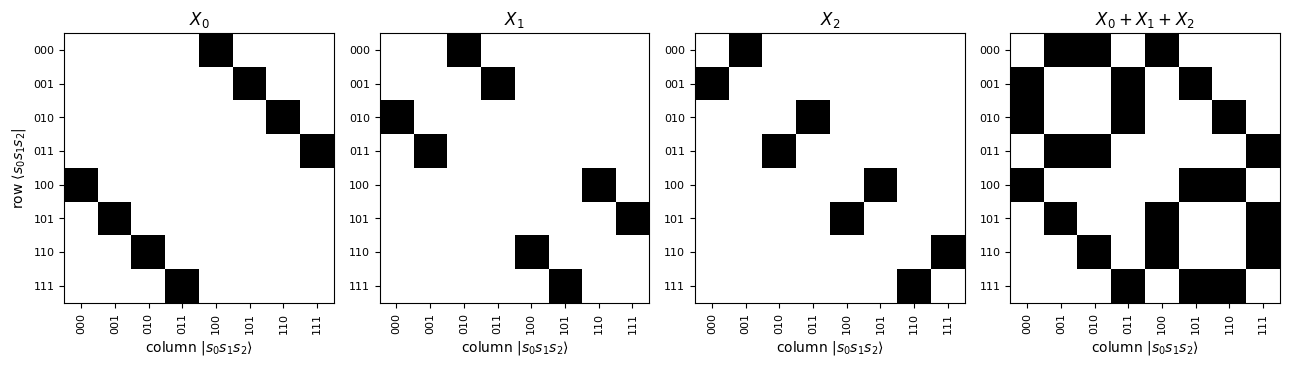

In [12]:
# ==============================================================================
# FIGURE: the matrices of X_j for N = 3
# ==============================================================================
N = 3
labels = ["".join(map(str, row)) for row in np.asarray(bits_table(N))]
mats = [site_operator(X, j, N) for j in range(N)]
mats.append(sum(mats))
titles = [rf"$X_{j} $" for j in range(N)] + [r"$X_0+X_1+X_2$"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, M, title in zip(axes, mats, titles):
    ax.imshow(np.asarray(M).real, cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks(range(2 ** N)); ax.set_yticks(range(2 ** N))
    ax.set_xticklabels(labels, rotation=90, fontsize=8); ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title); ax.set_xlabel(r"column $|s_0s_1s_2\rangle$")
axes[0].set_ylabel(r"row $\langle s_0s_1s_2|$")
plt.tight_layout(); plt.show()

Black squares are entries equal to 1, white is 0. $X_j$ connects each basis state with the state in which bit
$j$ is flipped, i.e. flat index $i$ with $i\oplus2^{N-1-j}$ (bitwise XOR): for $X_0$ (most significant bit)
the partner is $4$ positions away, for $X_1$ two positions, for $X_2$ it is the neighbour. Two lessons:

* each row of a site operator contains a **single** non-zero entry out of $2^N$ — the matrix is almost
  entirely zeros, and the sum of $N$ such operators has $N$ non-zeros per row. Hamiltonians of spin systems
  are extremely **sparse**. We will come back to this in Section 8.
* the non-zero pattern is fully determined by bit manipulations on the index. One never really *needs* the
  big matrix — this observation is the seed of the matrix-free approach of
  [notebook 05](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb).

### 4.3 The total magnetisation

The simplest collective observable is the **total magnetisation** along $z$,

$$ M_z = \sum_{j=0}^{N-1} Z_j \qquad\Big(\text{total spin } S^z_{\rm tot}=\tfrac12M_z\Big). $$

Every basis state is an eigenstate: $M_z|s_0\ldots s_{N-1}\rangle = (N_\uparrow-N_\downarrow)|s\rangle = (N-2k)|s\rangle$,
where $k=\sum_qs_q$ is the number of down spins. The eigenvalue $N-2k$ is shared by all
$\binom{N}{k}$ bit strings with $k$ ones. These **magnetisation sectors** will organise the spectrum of the
XXZ chain below. For later use we also define $M_x=\sum_jX_j$ and $M_y=\sum_jY_j$.

In [13]:
# ==============================================================================
# STEP 11: total magnetisation and its sectors
# ==============================================================================
from math import comb


def total_magnetisation(op, N):
    """M = sum_j op_j  as a dense 2^N x 2^N matrix (op = X, Y or Z)."""
    return sum(site_operator(op, j, N) for j in range(N))


def mz_diagonal(N):
    """The diagonal of M_z WITHOUT building any matrix:  M_z|s> = (N - 2 * number_of_ones(s)) |s>."""
    return N - 2 * bits_table(N).sum(axis=1)


N = 6
Mz = total_magnetisation(Z, N)
print("Checkpoint: total magnetisation, N =", N)
checkpoint("M_z is diagonal and equals N - 2*(number of down spins)", jnp.abs(Mz - jnp.diag(mz_diagonal(N).astype(CDTYPE))).max())
values, counts = np.unique(np.asarray(mz_diagonal(N)), return_counts=True)
print("  eigenvalue of M_z :", values)
print("  degeneracy        :", counts, " = binomial(N, k):", [comb(N, k) for k in range(N, -1, -1)])
assert list(counts) == [comb(N, k) for k in range(N, -1, -1)] and counts.sum() == 2 ** N

Checkpoint: total magnetisation, N = 6


  [ok] M_z is diagonal and equals N - 2*(number of down spins)    error = 0.00e+00
  eigenvalue of M_z : [-6 -4 -2  0  2  4  6]
  degeneracy        : [ 1  6 15 20 15  6  1]  = binomial(N, k): [1, 6, 15, 20, 15, 6, 1]


The degeneracies are the binomial coefficients $1,6,15,20,15,6,1$, which add up to $2^6=64$. The largest
sector, $M_z=0$, contains $\binom{6}{3}=20$ states.

> **Numerical practice.** `mz_diagonal` obtains the same information from the bit table with $O(N2^N)$
> integer operations and no matrix at all. A diagonal operator never needs to be stored as a matrix: keep the
> diagonal as a vector. We will use this for all $Z$-type observables below.

## 5. Model Hamiltonians and what they describe

We now let the spins interact. Throughout the course the spins live on a lattice — here a one-dimensional
**chain** of $N$ sites with nearest-neighbour bonds $\langle j,j+1\rangle$, with either **open** ends
($N-1$ bonds) or **periodic** boundary conditions (a ring, $N$ bonds: spin $N-1$ is coupled to spin 0). The
general Hamiltonian that our code will handle is, in Pauli convention,

$$ H = \sum_{\langle i,j\rangle}\big(J_{xx}X_iX_j + J_{yy}Y_iY_j + J_{zz}Z_iZ_j\big) + \sum_j\big(h_xX_j+h_yY_j+h_zZ_j\big). \qquad\text{(4)} $$

Special cases have names:

| model | couplings in Eq. (4) | Hamiltonian |
|---|---|---|
| **transverse-field Ising (TFIM)** | $J_{zz}=-J,\ h_x=-h$ | $H=-J\sum_jZ_jZ_{j+1}-h\sum_jX_j$ |
| **Heisenberg (XXX)** | $J_{xx}=J_{yy}=J_{zz}=J$ | $H=J\sum_j\boldsymbol\sigma_j\cdot\boldsymbol\sigma_{j+1}$ |
| **XXZ** | $J_{xx}=J_{yy}=J,\ J_{zz}=J\Delta$ | $H=J\sum_j\big(X_jX_{j+1}+Y_jY_{j+1}+\Delta Z_jZ_{j+1}\big)$ |
| **XY / XX** | $J_{zz}=0$ | $H=J\sum_j\big(X_jX_{j+1}+Y_jY_{j+1}\big)$ |

**The transverse-field Ising model.** The term $-JZ_jZ_{j+1}$ with $J>0$ is *ferromagnetic*: it gives energy
$-J$ to parallel neighbours and $+J$ to antiparallel ones, and on its own it has two ground states,
$|{\uparrow\uparrow\cdots\uparrow}\rangle$ and $|{\downarrow\downarrow\cdots\downarrow}\rangle$. The field
term $-hX_j$ does not commute with it: $X_j$ flips spin $j$, and on its own it has the unique ground state
$|{+}{+}\cdots{+}\rangle$, all spins pointing along $x$. The two terms *compete*: for $h\ll J$ the spins
order along $\pm z$ (**ferromagnetic phase**), for $h\gg J$ they align with the field
(**paramagnetic phase**). In the limit $N\to\infty$ the two regimes are separated by a **quantum phase
transition** at exactly $h=J$ — a change of the ground state as $h$ is tuned, caused by the competition
between the ordering coupling $ZZ$ and the spin flips caused by $X_j$. The TFIM is *the* textbook model of
quantum criticality (Sachdev's book devotes a chapter to it), and the chain can be solved exactly by mapping it to free
fermions (Pfeuty 1970), which gives us analytic results to test our numerics against. In the laboratory it
describes the Ising magnet CoNb$_2$O$_6$ in a transverse magnetic field (Coldea *et al.* 2010). Two quantum
simulators realise close relatives of it. In a **Rydberg-atom array** (Browaeys and Lahaye 2020) the two spin
states are the ground state and a Rydberg state; the driving laser of Rabi frequency $\Omega$ and detuning
$\delta$ contributes $\frac{\Omega}{2}\sum_jX_j-\delta\sum_jn_j$ with $n_j=(1-Z_j)/2$, and the van der Waals
repulsion between two excited atoms contributes $\sum_{i<j}(C_6/r_{ij}^6)\,n_in_j$. Rewriting $n_j$ in terms
of $Z_j$ turns this into an Ising model with transverse field $h=\Omega/2$, so the *transverse* field is half
the Rabi frequency — but the couplings are antiferromagnetic and fall off as $1/r^6$ instead of stopping at
nearest neighbours, and the detuning acts as an extra *longitudinal* field $h_z$, which the TFIM of Eq. (4)
does not have (Exercise 4 adds it). **Trapped-ion simulators** implement $\sum_{i<j}J_{ij}X_iX_j+B\sum_jZ_j$
with $J_{ij}\propto|i-j|^{-\alpha}$, $0<\alpha<3$: the same competition between one Ising and one transverse
term, again with long-range couplings.

**Heisenberg and XXZ models.** The exchange interaction between electron spins on neighbouring ions is
isotropic, $J\,\boldsymbol\sigma_i\cdot\boldsymbol\sigma_j$; $J>0$ favours antiparallel neighbours
(**antiferromagnet**), $J<0$ parallel ones. This is the basic model of magnetic insulators, e.g. the
spin-chain compounds KCuF$_3$ and Sr$_2$CuO$_3$. Writing $X_iX_j+Y_iY_j = 2(\sigma^+_i\sigma^-_j+\sigma^-_i\sigma^+_j)$
with $\sigma^\pm=(X\pm iY)/2$ shows what the "XY part" does ($\sigma^+=|{\uparrow}\rangle\langle{\downarrow}|$
raises a spin, $\sigma^-$ lowers it; beware that in qubit language, where $|1\rangle=|{\downarrow}\rangle$
counts as the "excited" state, the same matrix $|0\rangle\langle1|$ is called a *lowering* operator): it
moves a down spin from one site to its neighbour — it is a **hopping term**. If one reads "down spin" as "a
particle sits here", the XXZ chain is a model of hard-core bosons hopping on a lattice with
nearest-neighbour interaction $\Delta$. Ultracold atoms in a deep optical lattice realise the two ends of
this correspondence in different ways: bosons in the hard-core limit give the free-particle chain
$\Delta=0$ directly, while a two-component Mott insulator at unit filling has an effective
*superexchange* Hamiltonian of Heisenberg (or, with unequal tunnelling amplitudes, XXZ) form. In
superconducting-qubit processors the same hopping term arises from the capacitive coupling between
neighbouring qubits. The anisotropy $\Delta$ interpolates
between the XY chain ($\Delta=0$, free particles), the isotropic Heisenberg point ($\Delta=1$) and the
Ising-like antiferromagnet ($\Delta\gg1$). The chain was solved by Bethe in 1931 with his famous ansatz; its
ground-state energy per site in the thermodynamic limit (Hulthén 1938) is, in our Pauli convention,
$E_0/N = J\,(1-4\ln2)\approx-1.7726\,J$.

> **Physics insight.** In all these models the interesting physics comes from terms that **do not commute**.
> If all terms of $H$ commuted (e.g. $h=0$ in the TFIM), the basis states would be eigenstates, and there
> would be nothing to compute. Non-commuting terms force the eigenstates to be superpositions of
> exponentially many basis states — generically highly entangled ones.

## 6. Building the Hamiltonian matrix

### 6.1 `build_hamiltonian_dense`

**From formula to code.** Eq. (4) is a sum of site operators, and the code is a literal transcription: loop
over the bonds and add $J_{\alpha\alpha}\,\sigma^\alpha_i\sigma^\alpha_j$ (one `two_site_operator` per Pauli
component), then loop over the sites and add the field terms (`site_operator`). Terms with a vanishing
coefficient are skipped. The function signature mirrors Eq. (4) and will be reused, unchanged, in
[notebook 04](04_time_evolution_the_textbook_way.ipynb).

In [14]:
# ==============================================================================
# STEP 12: the dense many-body Hamiltonian
# ==============================================================================
def chain_bonds(N, periodic=False):
    """Nearest-neighbour bonds of a chain: (0,1), (1,2), ..., (N-2,N-1)  [+ (N-1,0) if periodic].

    The closing bond is added only for N > 2: on a "ring" of two spins the sites are already nearest
    neighbours through the bond (0,1), and adding (1,0) would count the same coupling twice.
    """
    return [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])


def build_hamiltonian_dense(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False):
    """Dense 2^N x 2^N matrix of the spin-1/2 chain Hamiltonian in Pauli convention.

    MATH
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_j (hx X_j + hy Y_j + hz Z_j)
        Heisenberg: Jxx=Jyy=Jzz   XXZ: Jxx=Jyy != Jzz   XY: Jzz=0   TFIM: Jzz=-J, hx=-h (all others 0).
    IMPLEMENTATION
        every term is one Kronecker chain (`two_site_operator` / `site_operator`), added to H.
        The coefficients are ordinary Python numbers, so `if J != 0` is a legal Python branch.
    COST
        (3*#bonds + 3*N) chains of O(4^N) each  ->  O(N 4^N) time, O(4^N) memory (16 bytes per entry).
    """
    H = jnp.zeros((2 ** N, 2 ** N), dtype=CDTYPE)
    for i, j in chain_bonds(N, periodic):                       # two-spin couplings
        for J, P in ((Jxx, X), (Jyy, Y), (Jzz, Z)):
            if J != 0:
                H = H + J * two_site_operator(P, i, P, j, N)
    for j in range(N):                                          # fields
        for h, P in ((hx, X), (hy, Y), (hz, Z)):
            if h != 0:
                H = H + h * site_operator(P, j, N)
    return H


def tfim_dense(N, J=1.0, h=1.0, periodic=False):
    """Transverse-field Ising chain  H = -J sum Z_j Z_{j+1} - h sum X_j."""
    return build_hamiltonian_dense(N, Jxx=0.0, Jyy=0.0, Jzz=-J, hx=-h, periodic=periodic)


def xxz_dense(N, J=1.0, Delta=1.0, periodic=False):
    """XXZ chain  H = J sum (X_j X_{j+1} + Y_j Y_{j+1} + Delta Z_j Z_{j+1});  Delta = 1: Heisenberg."""
    return build_hamiltonian_dense(N, Jxx=J, Jyy=J, Jzz=J * Delta, periodic=periodic)


# --- checkpoints ---------------------------------------------------------------------------------
print("Checkpoint: Hamiltonian builder")
checkpoint("N=2 Heisenberg == XX + YY + ZZ from Section 3.5", jnp.abs(xxz_dense(2) - H2).max())
H_test = build_hamiltonian_dense(5, Jxx=0.3, Jyy=-0.7, Jzz=1.1, hx=0.2, hy=0.5, hz=-0.4, periodic=True)
checkpoint("H is Hermitian (generic couplings, N=5, periodic)", jnp.abs(H_test - H_test.conj().T).max())
# independent construction: multiply full site operators (slow, O(8^N), but a different code path)
N = 4
H_slow = sum(-1.0 * site_operator(Z, i, N) @ site_operator(Z, j, N) for i, j in chain_bonds(N)) \
    + sum(-0.7 * site_operator(X, j, N) for j in range(N))
checkpoint("TFIM N=4 == sum of products of site operators", jnp.abs(tfim_dense(N, 1.0, 0.7) - H_slow).max())
# h = 0: the Ising term alone is diagonal, with energy -J * sum_j z_j z_{j+1},  z = +-1
z = 1 - 2 * bits_table(N)
E_classical = -(z[:, :-1] * z[:, 1:]).sum(axis=1)
checkpoint("TFIM at h=0 is diagonal with the classical Ising energies",
           jnp.abs(tfim_dense(N, 1.0, 0.0) - jnp.diag(E_classical.astype(CDTYPE))).max())

Checkpoint: Hamiltonian builder


  [ok] N=2 Heisenberg == XX + YY + ZZ from Section 3.5            error = 0.00e+00


  [ok] H is Hermitian (generic couplings, N=5, periodic)          error = 0.00e+00


  [ok] TFIM N=4 == sum of products of site operators              error = 0.00e+00


  [ok] TFIM at h=0 is diagonal with the classical Ising energies  error = 0.00e+00


The builder reproduces the two-spin result, returns a Hermitian matrix for arbitrary couplings, agrees with
an independent (slower) construction, and reduces to the classical Ising energies at $h=0$.

> **Common pitfall.** It is tempting to write $X_iX_j$ as `site_operator(X,i,N) @ site_operator(X,j,N)`.
> A dense matrix product of two $2^N\times2^N$ matrices costs $(2^N)^3=8^N$ operations, while the Kronecker
> chain of `two_site_operator` costs $4^N$. At $N=10$ that is a factor of a thousand.

A stronger test uses exact results. For the **periodic** TFIM the free-fermion solution (Pfeuty 1970; we
quote it without proof) gives the ground-state energy for $h>0$ and even $N$ as

$$ E_0 = -\sum_{m=0}^{N-1}\sqrt{J^2+h^2-2Jh\cos k_m},\qquad k_m=\frac{(2m+1)\pi}{N}. \qquad\text{(5)} $$

For the Heisenberg ring of four spins the ground-state energy is $E_0=-8J$ (exercise 3 asks you to derive
it with the total-spin trick of Section 3.5). Let us compare.

In [15]:
# ==============================================================================
# CHECKPOINT: ground-state energies against exact results
# ==============================================================================
def tfim_ring_energy_exact(N, J, h):
    """Exact ground-state energy of the periodic TFIM, Eq. (5) (free-fermion solution, even N, h > 0)."""
    k = (2 * np.arange(N) + 1) * np.pi / N
    return -np.sum(np.sqrt(J ** 2 + h ** 2 - 2 * J * h * np.cos(k)))


print("Checkpoint: exact ground-state energies")
for N in (4, 6, 8):
    for h in (0.5, 1.0, 1.5):
        E0 = jnp.linalg.eigvalsh(tfim_dense(N, 1.0, h, periodic=True))[0]          # eigenvalues only
        E_ex = tfim_ring_energy_exact(N, 1.0, h)
        checkpoint(f"TFIM ring N={N}, h={h}: E0 = {float(E0):+.10f}", abs(float(E0) - E_ex) / abs(E_ex))
checkpoint("Heisenberg ring N=4: E0 = -8", jnp.abs(jnp.linalg.eigvalsh(xxz_dense(4, periodic=True))[0] + 8.0) / 8.0)

Checkpoint: exact ground-state energies


  [ok] TFIM ring N=4, h=0.5: E0 = -4.2715584101                   error = 4.16e-16
  [ok] TFIM ring N=4, h=1.0: E0 = -5.2262518595                   error = 1.70e-16
  [ok] TFIM ring N=4, h=1.5: E0 = -6.7600085506                   error = 1.31e-16


  [ok] TFIM ring N=6, h=0.5: E0 = -6.3846945636                   error = 1.39e-16


  [ok] TFIM ring N=6, h=1.0: E0 = -7.7274066103                   error = 1.15e-15


  [ok] TFIM ring N=6, h=1.5: E0 = -10.0569464232                  error = 0.00e+00


  [ok] TFIM ring N=8, h=0.5: E0 = -8.5090822351                   error = 6.26e-16


  [ok] TFIM ring N=8, h=1.0: E0 = -10.2516617910                  error = 1.73e-16


  [ok] TFIM ring N=8, h=1.5: E0 = -13.3850052332                  error = 2.65e-16
  [ok] Heisenberg ring N=4: E0 = -8                               error = 2.22e-16


Nine ground-state energies agree with the analytic formula to a relative error of $10^{-15}$ (machine
precision). This is strong evidence that the builder, the index conventions *and* the boundary conditions are
right — an error in any of them would change the energy in the first or second digit.

### 6.2 Symmetries

An operator $Q$ with $[H,Q]=0$ is a **symmetry** (a conserved quantity). Symmetries are both physics and
numerics: $H$ cannot connect eigenstates of $Q$ with different eigenvalues, so in a basis sorted by the
eigenvalue of $Q$ the Hamiltonian matrix is **block diagonal**, and each block can be diagonalised
separately.

**XXZ chain: conservation of $M_z$.** The $ZZ$ terms are diagonal and trivially commute with $M_z$. The
hopping term $X_iX_j+Y_iY_j=2(\sigma^+_i\sigma^-_j+\sigma^-_i\sigma^+_j)$ flips one spin up and another one
down — the number of down spins does not change. Hence $[H_{XXZ},M_z]=0$. (At the Heisenberg point
$\Delta=1$ all three components $M_x,M_y,M_z$ are conserved: the model is invariant under global spin
rotations, the symmetry group SU(2).)

**TFIM: spin-flip parity.** The field term $X_j$ changes the number of down spins by one, so $M_z$ is *not*
conserved. But the operator that flips **all** spins,

$$ P = \prod_jX_j = X\otimes X\otimes\cdots\otimes X,\qquad P^2=1, $$

is a symmetry: $P$ commutes with every $X_j$, and $PZ_jP=-Z_j$ (because $XZX=-Z$), so $PZ_iZ_jP=Z_iZ_j$. The
eigenvalues of $P$ are $\pm1$ ("even" and "odd" parity). This $\mathbb Z_2$ symmetry is the one that is
*spontaneously broken* in the ferromagnetic phase. It has an important consequence for finite systems: in any
non-degenerate eigenstate, $P|\psi\rangle=\pm|\psi\rangle$ and therefore

$$ \langle\psi|Z_j|\psi\rangle = \langle\psi|P\,Z_j\,P|\psi\rangle = -\langle\psi|Z_j|\psi\rangle = 0 . $$

*The magnetisation $\langle Z_j\rangle$ of a finite TFIM chain vanishes identically, even deep in the
"ferromagnetic" phase.* We will have to be smarter to see the order (Section 7.4).

**Periodic chains: translation.** On a ring the operator $T$ that shifts every spin by one site,
$T|s_0s_1\ldots s_{N-1}\rangle = |s_{N-1}s_0\ldots s_{N-2}\rangle$, maps each bond onto the next and
therefore commutes with every Hamiltonian of the form (4) with uniform couplings. Since $T^N=1$, its
eigenvalues are the $N$-th roots of unity $e^{ik}$ with lattice momentum $k=2\pi n/N$, $n=0,\ldots,N-1$: a
ring splits into $N$ momentum sectors, each roughly $2^N/N$ states large, and they can be combined with the
$M_z$ sectors above. Translation invariance is also the reason why the correlation function of Section 7.5
depends on the distance $r$ alone, $\langle Z_iZ_j\rangle = C(|i-j|)$. An open chain has no translation
symmetry (the end sites have one neighbour instead of two), only the reflection $j\mapsto N-1-j$. We do not
exploit momentum sectors anywhere in this notebook; they are listed here because together with $M_z$ they
are what a production exact-diagonalisation code uses to push $N$ as far as it goes.

In [16]:
# ==============================================================================
# STEP 13: symmetry checks
# ==============================================================================
N = 6
H_xxz = xxz_dense(N, J=1.0, Delta=0.5)
H_heis = xxz_dense(N, J=1.0, Delta=1.0)
H_tfim = tfim_dense(N, J=1.0, h=0.8)
Mx, My, Mz = (total_magnetisation(P, N) for P in (X, Y, Z))
parity = kron_chain([X] * N)                                   # P = X (x) X (x) ... (x) X

print("Checkpoint: symmetries, N =", N)
checkpoint("[H_XXZ, M_z] = 0", jnp.abs(commutator(H_xxz, Mz)).max())
checkpoint("[H_Heisenberg, M_x] = [H, M_y] = [H, M_z] = 0   (SU(2))",
           sum(jnp.abs(commutator(H_heis, M)).max() for M in (Mx, My, Mz)))
checkpoint("P^2 = 1", jnp.abs(parity @ parity - jnp.eye(2 ** N)).max())
checkpoint("[H_TFIM, P] = 0", jnp.abs(commutator(H_tfim, parity)).max())
print(f"  for contrast: max|[H_XXZ, M_x]| = {float(jnp.abs(commutator(H_xxz, Mx)).max()):.2f},"
      f"  max|[H_TFIM, M_z]| = {float(jnp.abs(commutator(H_tfim, Mz)).max()):.2f}   (NOT symmetries)")

Checkpoint: symmetries, N = 6
  [ok] [H_XXZ, M_z] = 0                                           error = 0.00e+00
  [ok] [H_Heisenberg, M_x] = [H, M_y] = [H, M_z] = 0   (SU(2))    error = 0.00e+00


  [ok] P^2 = 1                                                    error = 0.00e+00
  [ok] [H_TFIM, P] = 0                                            error = 0.00e+00
  for contrast: max|[H_XXZ, M_x]| = 2.00,  max|[H_TFIM, M_z]| = 1.60   (NOT symmetries)


The block structure can be made visible. We plot the non-zero pattern of $H_{XXZ}$ for $N=6$ twice: in the
natural basis order of Eq. (2), and after sorting the basis states by their magnetisation (a permutation of
rows and columns, `H[order][:, order]`).

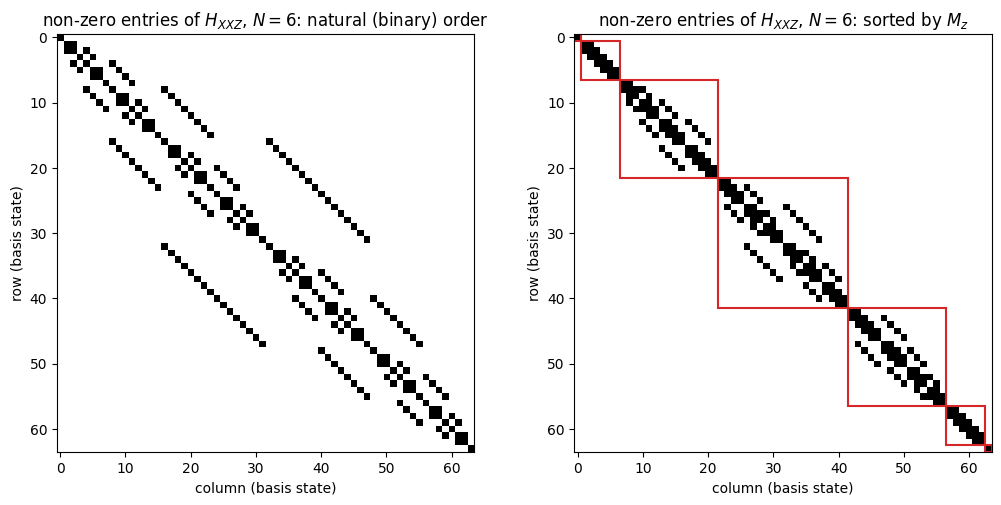

largest matrix element between different M_z sectors: 0.0e+00
non-zero entries: 224 of 4096  (5.5 %)


In [17]:
# ==============================================================================
# FIGURE: block structure of the XXZ Hamiltonian in the magnetisation basis
# ==============================================================================
mz = np.asarray(mz_diagonal(N))
order = np.argsort(-mz, kind="stable")                         # sort basis states by M_z = N, N-2, ..., -N
H_sorted = np.asarray(H_xxz)[order][:, order]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5))
for ax, M, title in ((axes[0], np.asarray(H_xxz), "natural (binary) order"), (axes[1], H_sorted, r"sorted by $M_z$")):
    ax.imshow(np.abs(M) > 0, cmap="Greys", interpolation="nearest")
    ax.set_title(rf"non-zero entries of $H_{{XXZ}}$, $N={N}$: {title}")
    ax.set_xlabel("column (basis state)"); ax.set_ylabel("row (basis state)")
edges = np.cumsum([comb(N, k) for k in range(N + 1)])          # sector sizes 1, 6, 15, 20, 15, 6, 1
for e0, e1 in zip(np.r_[0, edges[:-1]], edges):
    axes[1].add_patch(plt.Rectangle((e0 - 0.5, e0 - 0.5), e1 - e0, e1 - e0, fill=False, edgecolor="C3", lw=1.5))
plt.tight_layout(); plt.show()
off_block = np.abs(H_sorted) * (mz[order][:, None] != mz[order][None, :])
print(f"largest matrix element between different M_z sectors: {off_block.max():.1e}")
print(f"non-zero entries: {np.count_nonzero(H_sorted)} of {H_sorted.size}  ({100 * np.count_nonzero(H_sorted) / H_sorted.size:.1f} %)")

Left: in the binary order the conservation law is hidden. Right: after sorting, all non-zero entries fall into
the red diagonal blocks of sizes $\binom{6}{k}=1,6,15,20,15,6,1$; no matrix element connects different
sectors. Instead of one $64\times64$ problem we could solve seven small ones, the largest being
$20\times20$. For large $N$ the biggest sector still grows like $2^N/\sqrt N$, so symmetries *postpone* the
exponential wall by a few spins but do not remove it. In this notebook we keep the full matrix for simplicity
(exercise 6 asks you to diagonalise a single sector). The matrix is also almost empty: only about 5 % of
the entries are non-zero already at $N=6$.

## 7. Exact diagonalisation

### 7.1 The eigenvalue problem and how to check it

The stationary Schrödinger equation $H|\phi_n\rangle=E_n|\phi_n\rangle$ is a matrix eigenvalue problem. For a
Hermitian matrix the standard dense algorithm first reduces $H$ to tridiagonal form by a sequence of
Householder reflections, then diagonalises the tridiagonal matrix (by QR iteration or by a divide-and-conquer
recursion; the latter is what LAPACK's `?syevd` — the routine behind `jnp.linalg.eigh` — uses). It returns
**all** $2^N$ eigenvalues and eigenvectors, at a cost of $O(d^3)$ operations and $O(d^2)$ memory for a
$d\times d$ matrix. With $d=2^N$ that is

$$ \text{time}\sim 8^N,\qquad \text{memory}\sim4^N . $$

`jnp.linalg.eigvalsh` computes the eigenvalues only, which is a few times cheaper.

> **Numerical practice.** The Hamiltonians (4) with $h_y=0$ are **real symmetric** matrices: $X$ and $Z$ are
> real, and $Y\otimes Y$ is real because the two factors of $i$ multiply to a real number. Real arithmetic
> halves the memory and makes `eigh` noticeably faster, and the eigenvectors can be chosen real. The helper
> `as_real` below drops the imaginary part *after checking that it vanishes*.

The phrase "to machine precision" needs a practical rule attached to it. A backward-stable symmetric
eigensolver returns the *exact* eigenvalues of a perturbed matrix $H+\delta H$ with
$\lVert\delta H\rVert=O(\varepsilon)\lVert H\rVert$, and Weyl's inequality then bounds each eigenvalue error
by $\lVert\delta H\rVert$. The error is therefore **absolute, not relative**:

$$ \delta E \approx c\,\varepsilon\,\lVert H\rVert, \qquad
   \lVert H\rVert \le \sum_{\alpha}\big(\lvert J_{\alpha\alpha}\rvert\,n_{\rm bonds} + \lvert h_\alpha\rvert\,N\big), \qquad\text{(6)} $$

with $\varepsilon=2.2\cdot10^{-16}$ in double precision and $1.2\cdot10^{-7}$ in single, and $c$ a modest
factor (a small power of the matrix dimension in the worst case).

> **Numerical practice.** For the critical TFIM at $N=12$ the bound of Eq. (6) gives
> $\lVert H\rVert\le2NJ=24$, so double precision resolves energy *differences* down to about $10^{-14}$ and
> single precision only down to about $10^{-5}$; anything smaller is noise, whatever the number of digits
> printed. This is why the exponentially small doublet splitting $E_1-E_0\sim J(h/J)^N$ of Section 7.2 is the
> first casualty of reduced precision (Exercise 8), while the energy per site itself keeps eight digits.

Never trust an eigensolver blindly. Three cheap tests: the residual $\lVert Hv-Ev\rVert$, the orthonormality
$V^\dagger V=1$, and the trace identity $\sum_nE_n=\mathrm{Tr}\,H$.

In [18]:
# ==============================================================================
# STEP 14: exact diagonalisation of the TFIM, N = 8, with sanity checks
# ==============================================================================
def as_real(H):
    """Return H as a real matrix after verifying that its imaginary part vanishes (true if hy = 0)."""
    assert float(jnp.abs(jnp.imag(H)).max()) < TOL, "H is not real: keep the complex matrix"
    return jnp.real(H)


N, J, h = 8, 1.0, 0.8
H = as_real(tfim_dense(N, J, h))
E, V = jnp.linalg.eigh(H)                                       # E: (256,) ascending;  V[:, n] = n-th eigenvector
print(f"TFIM, N={N}, h/J={h}: matrix {H.shape}, dtype {H.dtype}")
print("lowest five energies:", np.round(np.asarray(E[:5]), 6))
print("Checkpoint: eigensolver")
checkpoint("residual max_n ||H v_n - E_n v_n||", jnp.abs(H @ V - V * E[None, :]).max())
checkpoint("orthonormality ||V^T V - 1||", jnp.abs(V.T @ V - jnp.eye(2 ** N)).max())
checkpoint("sum of eigenvalues = Tr H (= 0 here)", jnp.abs(E.sum() - jnp.trace(H)))
# parity of the two lowest eigenstates (Section 6.2); the amplitudes of the ground state have one sign
P8 = as_real(kron_chain([X] * N))
print(f"parity <P> of the ground state: {float(V[:, 0] @ P8 @ V[:, 0]):+.6f},  of the first excited state: {float(V[:, 1] @ P8 @ V[:, 1]):+.6f}")
print(f"<Z_0> in the ground state: {float(expval(V[:, 0].astype(CDTYPE), site_operator(Z, 0, N))):+.1e}   (zero by symmetry)")

TFIM, N=8, h/J=0.8: matrix (256, 256), dtype float64


lowest five energies: [-8.749171 -8.618973 -7.767244 -7.637046 -7.146601]
Checkpoint: eigensolver


  [ok] residual max_n ||H v_n - E_n v_n||                         error = 4.25e-15


  [ok] orthonormality ||V^T V - 1||                               error = 2.44e-15


  [ok] sum of eigenvalues = Tr H (= 0 here)                       error = 2.84e-14


parity <P> of the ground state: +1.000000,  of the first excited state: -1.000000


<Z_0> in the ground state: -7.3e-15   (zero by symmetry)


The solver passes all tests. The two lowest states have opposite parity ($+1$ and $-1$) and are separated by
a small energy; and, as predicted in Section 6.2, $\langle Z_0\rangle=0$ in the ground state even though
$h<J$. We now turn the crank and extract physics.

### 7.2 The energy gap of the TFIM and the quantum critical point

The **energy gap** $\Delta = E_1-E_0$ between the ground state and the first excited state is the most
important number of a quantum many-body system: it sets the energy (and time) scale of the low-energy
physics, it controls the decay of correlations, and at a continuous quantum phase transition it must
**close**. For the infinite TFIM chain the exact solution gives the energy of an elementary excitation as
$\Delta_\infty = 2|h-J|$:

* $h>J$ (paramagnet): the excitation is a single spin flipped against the field, costing $2h$ at $J=0$, which
  lowers its energy to $2(h-J)$ by hopping along the chain;
* $h<J$ (ferromagnet): the excitation is a **domain wall** (kink) between an up and a down region, costing
  $2J$ at $h=0$ and $2(J-h)$ once the field lets it move.

In a *finite* chain the picture is subtler. For $h<J$ the two ordered states
$|{\Uparrow}\rangle=|{\uparrow\cdots\uparrow}\rangle$ and $|{\Downarrow}\rangle$ are coupled only in $N$-th
order of perturbation theory (all $N$ spins must be flipped), so the true eigenstates are the parity
eigenstates $(|{\Uparrow}\rangle\pm|{\Downarrow}\rangle)/\sqrt2$, split by a tiny energy
$E_1-E_0\sim J(h/J)^N$. The physical excitation gap in this phase is therefore $E_2-E_0$. We compute both.

**From formula to code.** The Hamiltonian is linear in the field, $H(h)=-J\,H_{zz}-h\,M_x$ with
$H_{zz}=\sum_jZ_jZ_{j+1}$ and $M_x=\sum_jX_j$, so we build the two matrices **once** and combine them for
every $h$ (`tfim_parts`). The function `tfim_solve` diagonalises $H(h)$ for **one** field value and returns
the lowest levels plus two ground-state observables (used in Section 7.4). The sweep over all field values
is then `jax.vmap` of that function, wrapped in `jax.jit`, so the whole sweep is one compiled program (see
[notebook 01](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) for both transformations). At the end of the cell we compare it
with a plain Python loop over the fields; `timed` is a small stopwatch that respects JAX's asynchronous
execution.

In [19]:
# ==============================================================================
# STEP 15: TFIM sweep over the transverse field (open chain)
# ==============================================================================
# ---- PARAMETERS ------------------------------------------------------------------------------------
J = 1.0                                         # Ising coupling (sets the unit of energy)
FIELDS = jnp.linspace(0.0, 2.0, 41)             # transverse fields h/J
SWEEP_SIZES = (4, 6, 8, 10)                     # chain lengths of the sweep
N_LEVELS = 8                                    # number of low-lying levels to keep
# ---------------------------------------------------------------------------------------------------


def timed(fn, *args):
    """Run fn(*args), wait for the result to be ready, return (result, elapsed seconds)."""
    t0 = time.perf_counter()
    out = fn(*args)
    jax.block_until_ready(out)
    return out, time.perf_counter() - t0


def tfim_parts(N):
    """The field-independent pieces of the open TFIM chain, built ONCE: (H_zz, M_x, diagonal of M_z).

    MATH   H(h) = -J H_zz - h M_x ,   H_zz = sum_j Z_j Z_{j+1} ,   M_x = sum_j X_j     (real dense matrices)
    """
    H_zz = as_real(build_hamiltonian_dense(N, Jxx=0.0, Jyy=0.0, Jzz=1.0))
    M_x = as_real(build_hamiltonian_dense(N, Jxx=0.0, Jyy=0.0, Jzz=0.0, hx=1.0))
    return H_zz, M_x, mz_diagonal(N).astype(H_zz.dtype)


def tfim_solve(h, H_zz, M_x, mz, J=1.0, n_levels=8):
    """Diagonalise H(h) for ONE field value; return the lowest levels and two ground-state observables.

    MATH   m_x = <M_x>/N ;   m_z^2 = <M_z^2>/N^2 = sum_s |psi_s|^2 m_s^2 / N^2    (M_z is diagonal)
    """
    N = int(np.log2(H_zz.shape[0]))
    E, V = jnp.linalg.eigh(-J * H_zz - h * M_x)
    gs = V[:, 0]                                                # ground state (a real vector)
    m_x = gs @ (M_x @ gs) / N
    m_z2 = jnp.sum(gs ** 2 * mz ** 2) / N ** 2
    return E[:n_levels], m_x, m_z2


# JAX: vmap maps `tfim_solve` over argument 0 (the fields) and broadcasts the matrices (in_axes=None);
# jit compiles the whole sweep into one XLA program.  The big matrices are passed as ARGUMENTS on purpose:
# arrays captured from an enclosing scope would be baked into the compiled program as constants.
solve = partial(tfim_solve, J=J, n_levels=N_LEVELS)             # fix the static parameters
tfim_sweep = jax.jit(jax.vmap(solve, in_axes=(0, None, None, None)))

sweep = {}
for N in SWEEP_SIZES:
    parts = tfim_parts(N)
    t0 = time.perf_counter()
    out = tfim_sweep(FIELDS, *parts)
    jax.block_until_ready(out)                                  # JAX is asynchronous: wait before reading the clock
    sweep[N] = out
    print(f"N = {N:2d}: {len(FIELDS)} diagonalisations of a {2 ** N:4d} x {2 ** N:<4d} matrix in {time.perf_counter() - t0:6.2f} s (incl. compilation)")

# --- performance aside: what do jit + vmap buy us?  (N = 6, second call = compiled code, no compilation) -----
parts = tfim_parts(6)
python_loop = lambda: [solve(h, *parts) for h in FIELDS]
timed(python_loop)                                                       # warm-up: fills JAX's per-operation caches
_, t_loop = timed(python_loop)                                                 # plain Python loop, op-by-op dispatch
_, t_vmap = timed(lambda: tfim_sweep(FIELDS, *parts))                    # one compiled, batched program
print(f"N = 6 sweep:  Python loop {1e3 * t_loop:8.1f} ms   |   jit(vmap) {1e3 * t_vmap:8.1f} ms   (speed-up x{t_loop / t_vmap:.0f})")

N =  4: 41 diagonalisations of a   16 x 16   matrix in   0.73 s (incl. compilation)


N =  6: 41 diagonalisations of a   64 x 64   matrix in   2.88 s (incl. compilation)


N =  8: 41 diagonalisations of a  256 x 256  matrix in  45.10 s (incl. compilation)


N = 10: 41 diagonalisations of a 1024 x 1024 matrix in 231.16 s (incl. compilation)


N = 6 sweep:  Python loop   5432.5 ms   |   jit(vmap)   1092.5 ms   (speed-up x5)


> **JAX practice.** The last line compares two ways of running the same 41 diagonalisations for $N=6$. The
> Python loop dispatches every operation of every field value separately (build $H(h)$, `eigh`, slicing,
> matrix–vector products, ...), each with a small overhead; `jit(vmap(...))` sends **one** compiled, batched
> program to the device. For small matrices the overhead dominates, and the compiled sweep is several times
> faster. Do not expect the same gain for $N=10$: there the time is spent inside the eigensolver itself, and
> no transformation changes its $O(8^N)$ arithmetic. `jit` and `vmap` remove overhead; they do not change the
> algorithm.

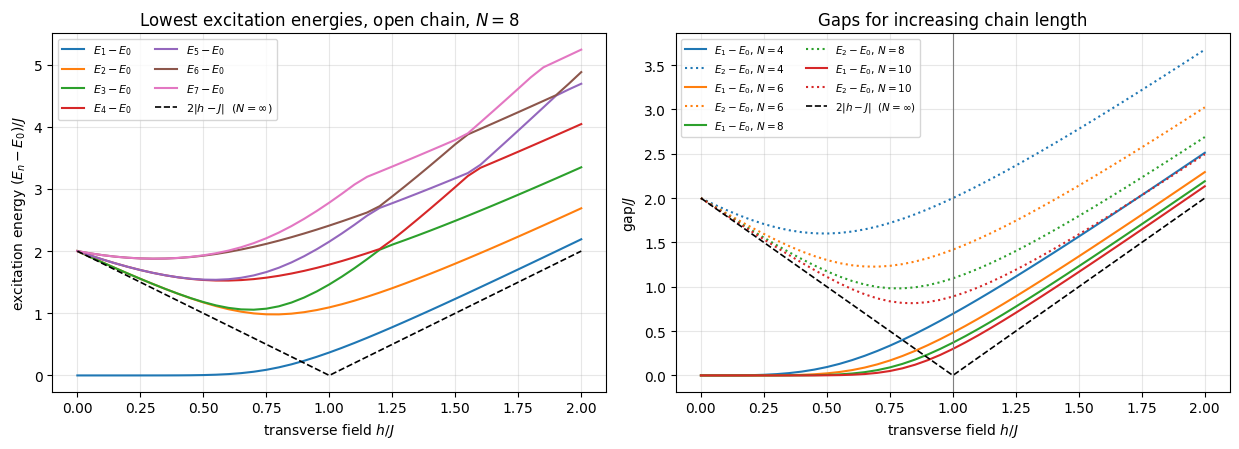

N=10, h/J=0.50:  E1-E0 = 0.001465   E2-E0 = 1.111668   2|h-J| = 1.00
N=10, h/J=1.00:  E1-E0 = 0.298920   E2-E0 = 0.890084   2|h-J| = 0.00
N=10, h/J=1.50:  E1-E0 = 1.167238   E2-E0 = 1.591573   2|h-J| = 1.00


In [20]:
# ==============================================================================
# FIGURE: low-energy spectrum and gaps of the TFIM
# ==============================================================================
h_over_J = np.asarray(FIELDS) / J
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
N_show = 8
levels = np.asarray(sweep[N_show][0])
for n in range(1, N_LEVELS):
    ax.plot(h_over_J, levels[:, n] - levels[:, 0], "-", color=f"C{(n - 1) % 10}", label=rf"$E_{n}-E_0$")
ax.plot(h_over_J, 2 * np.abs(h_over_J - 1), "k--", lw=1.2, label=r"$2|h-J|$  ($N=\infty$)")
ax.set_xlabel(r"transverse field $h/J$"); ax.set_ylabel(r"excitation energy $(E_n-E_0)/J$")
ax.set_title(rf"Lowest excitation energies, open chain, $N={N_show}$"); ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)
ax = axes[1]
for c, N in enumerate(SWEEP_SIZES):
    lv = np.asarray(sweep[N][0])
    ax.plot(h_over_J, lv[:, 1] - lv[:, 0], "-", color=f"C{c}", label=rf"$E_1-E_0$, $N={N}$")
    ax.plot(h_over_J, lv[:, 2] - lv[:, 0], ":", color=f"C{c}", label=rf"$E_2-E_0$, $N={N}$")
ax.plot(h_over_J, 2 * np.abs(h_over_J - 1), "k--", lw=1.2, label=r"$2|h-J|$  ($N=\infty$)")
ax.axvline(1.0, color="0.5", lw=0.8)
ax.set_xlabel(r"transverse field $h/J$"); ax.set_ylabel(r"gap$/J$")
ax.set_title("Gaps for increasing chain length"); ax.grid(alpha=0.3); ax.legend(fontsize=7.5, ncol=2)
plt.tight_layout(); plt.show()

lv = np.asarray(sweep[SWEEP_SIZES[-1]][0])
for hv in (0.5, 1.0, 1.5):
    k = int(np.argmin(np.abs(h_over_J - hv)))
    print(f"N={SWEEP_SIZES[-1]}, h/J={h_over_J[k]:.2f}:  E1-E0 = {lv[k, 1] - lv[k, 0]:.6f}   E2-E0 = {lv[k, 2] - lv[k, 0]:.6f}   2|h-J| = {2 * abs(h_over_J[k] - 1):.2f}")

**Reading the figure.** *Left:* at $h=0$ the levels are the classical Ising energies: a doubly degenerate
ground state, then the domain-wall states at $2J$. With increasing field the ground-state doublet stays
(almost) degenerate until $h\approx J$, where it splits and $E_1-E_0$ becomes the single-spin-flip gap of the
paramagnet; the band of domain-wall states comes down towards $h=J$ and turns into the band of spin-flip
states. *Right:* for $h>J$ the gap $E_1-E_0$ (solid) approaches the infinite-chain result $2(h-J)$ (dashed
black) from above as $N$ grows, and for $h<J$ the excitation gap $E_2-E_0$ (dotted) does the same with
$2(J-h)$, while $E_1-E_0$ is exponentially small. The numbers printed for the longest chain quantify this.

The minimum of the gap sits near $h=J$ and **decreases with $N$**: this is the *finite-size precursor of the
quantum critical point*. A finite system has no true phase transition — the gap never closes and everything
is smooth — but the sequence $N=4,6,8,10$ clearly points to a gap closing in the limit $N\to\infty$ at
$h=J$. How fast does it close? We study this next, and use the occasion to start a stopwatch.

### 7.3 The gap at the critical point versus $N$ — with a stopwatch

At $h=J$ the free-fermion solution of the open chain gives the gap in closed form (quoted without proof):

$$ \Delta_N(h=J) = 4J\sin\frac{\pi}{2(2N+1)} \;\xrightarrow{N\gg1}\; \frac{\pi J}{N}. \qquad\text{(7)} $$

The gap closes as a **power law** $\Delta\sim N^{-z}$ with dynamical critical exponent $z=1$; away from the
critical point it converges exponentially fast to a constant. In the next cell we diagonalise the critical
chain for $N=2,\ldots,12$. For every $N$ we record the wall-clock time of building $H$ and of `eigh`, as well
as the memory taken by $H$ — the raw material for Section 8.

> **JAX practice: honest timing.** (i) JAX dispatches work asynchronously, so we call `.block_until_ready()`
> before reading the clock. (ii) The first call of a JAX function with a new array *shape* includes
> compilation. Every size $N$ has its own shapes, so *every* row of the table would otherwise pay that price:
> we therefore call `tfim_dense` once as a warm-up and time the second call, and for $N\le10$ we time `eigh`
> twice and report both the first call (compile + run) and the second call (run only). For $N\ge11$ a second
> `eigh` would only cost time without adding information: the compile overhead (a fraction of a second, as
> the small sizes show) is negligible against several seconds of arithmetic.

In [21]:
# ==============================================================================
# STEP 16: critical TFIM chain for N = 2..12 -- gap, run time and memory
# ==============================================================================
# ---- PARAMETERS ------------------------------------------------------------------------------------
WALL_SIZES = range(2, 13)                       # N = 12: a 4096 x 4096 matrix, a few seconds. Lower if needed.
# ---------------------------------------------------------------------------------------------------


BYTES = np.dtype(CDTYPE).itemsize                # bytes per complex number: 16 (double) or 8 (single precision)
IDX_BYTES = 4                                    # bytes per 32-bit column index of a sparse matrix


def human(nbytes):
    """Format a number of bytes with binary prefixes (1 kB = 1024 B)."""
    for unit in ("B", "kB", "MB", "GB", "TB", "PB", "EB", "ZB", "YB"):
        if nbytes < 1024:
            return f"{nbytes:7.1f} {unit:<2s}"
        nbytes /= 1024
    return f"{nbytes:7.1e} YB"


wall = []                                        # rows: (N, gap, t_build, t_eigh_first, t_eigh_run, bytes_complex, nnz)
print("  N |  dim  |  gap E1-E0   | Eq. (7)      | build H [s] | eigh 1st [s] | eigh run [s] | H (complex) | non-zeros")
for N in WALL_SIZES:
    timed(tfim_dense, N, 1.0, 1.0)                               # warm-up: XLA compiles one program per array SHAPE,
    Hc, t_build = timed(tfim_dense, N, 1.0, 1.0)                 # so the second call measures the arithmetic alone
    nnz = int(jnp.count_nonzero(Hc))
    Hr = as_real(Hc)
    nbytes = Hc.nbytes
    del Hc                                                        # free the complex copy before the heavy step
    (E, V), t_first = timed(jnp.linalg.eigh, Hr)
    t_run = timed(jnp.linalg.eigh, Hr)[1] if N <= 10 else float("nan")
    gap = float(E[1] - E[0])
    wall.append((N, gap, t_build, t_first, t_run, nbytes, nnz))
    print(f" {N:2d} | {2 ** N:5d} | {gap:.10f} | {4 * np.sin(np.pi / (2 * (2 * N + 1))):.10f} |"
          f" {t_build:11.3f} | {t_first:12.3f} | {t_run:12.3f} | {nbytes / 2 ** 20:8.2f} MB | {nnz:8d}")
    del Hr, V
wall = np.array(wall)

print("Checkpoint: critical gap")
checkpoint("gap(N) = 4 J sin(pi / (2(2N+1))) for all N   [Eq. (7)]",
           np.abs(wall[:, 1] - 4 * np.sin(np.pi / (2 * (2 * wall[:, 0] + 1)))).max())

  N |  dim  |  gap E1-E0   | Eq. (7)      | build H [s] | eigh 1st [s] | eigh run [s] | H (complex) | non-zeros


  2 |     4 | 1.2360679775 | 1.2360679775 |       0.002 |        0.338 |        0.000 |     0.00 MB |       12


  3 |     8 | 0.8900837358 | 0.8900837358 |       0.002 |        0.297 |        0.000 |     0.00 MB |       28


  4 |    16 | 0.6945927107 | 0.6945927107 |       0.003 |        0.301 |        0.000 |     0.00 MB |       80


  5 |    32 | 0.5692593531 | 0.5692593531 |       0.017 |        0.393 |        0.025 |     0.02 MB |      180


...

  8 |   256 | 0.3690734379 | 0.3690734379 |       0.052 |        8.360 |        6.287 |     1.00 MB |     2304


  9 |   512 | 0.3303173819 | 0.3303173819 |       0.106 |       19.216 |       18.052 |     4.00 MB |     4980


 10 |  1024 | 0.2989203743 | 0.2989203743 |       0.631 |       43.454 |       44.007 |    16.00 MB |    11264


 11 |  2048 | 0.2729696535 | 0.2729696535 |       3.614 |       66.662 |          nan |    64.00 MB |    24072


 12 |  4096 | 0.2511620781 | 0.2511620781 |      18.260 |      199.902 |          nan |   256.00 MB |    53248
Checkpoint: critical gap
  [ok] gap(N) = 4 J sin(pi / (2(2N+1))) for all N   [Eq. (7)]     error = 5.72e-15


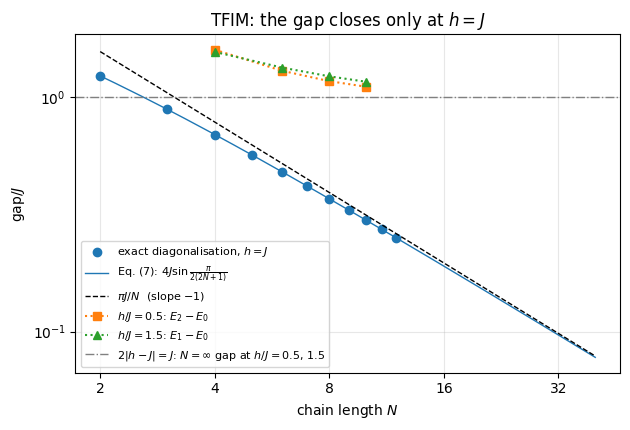

In [22]:
# ==============================================================================
# FIGURE: closing of the gap at the critical point
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.4, 4.4))
Ns = wall[:, 0]
ax.loglog(Ns, wall[:, 1], "o", color="C0", label=r"exact diagonalisation, $h=J$")
N_fine = np.linspace(2, 40, 200)
ax.loglog(N_fine, 4 * np.sin(np.pi / (2 * (2 * N_fine + 1))), "-", color="C0", lw=1, label=r"Eq. (7): $4J\sin\frac{\pi}{2(2N+1)}$")
ax.loglog(N_fine, np.pi / N_fine, "k--", lw=1, label=r"$\pi J/N$  (slope $-1$)")
for c, (hv, mk) in enumerate(((0.5, "s"), (1.5, "^")), start=1):  # off-critical gaps from the sweep, for contrast
    k = int(np.argmin(np.abs(h_over_J - hv)))
    col = 2 if hv < 1 else 1                                       # physical gap: E2-E0 for h<J, E1-E0 for h>J
    ax.loglog(SWEEP_SIZES, [float(sweep[N][0][k, col] - sweep[N][0][k, 0]) for N in SWEEP_SIZES], mk + ":",
              color=f"C{c}", label=rf"$h/J={hv}$: $E_{col}-E_0$")
ax.axhline(1.0, color="0.5", lw=1, ls="-.", label=r"$2|h-J|=J$: $N=\infty$ gap at $h/J=0.5,\,1.5$")
ax.set_xticks([2, 4, 8, 16, 32]); ax.set_xticklabels(["2", "4", "8", "16", "32"]); ax.minorticks_off()
ax.set_xlabel(r"chain length $N$"); ax.set_ylabel(r"gap$/J$"); ax.set_title("TFIM: the gap closes only at $h=J$")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The numerical gaps agree with Eq. (7) to machine precision for every $N$, and on the log–log plot they
approach the straight line $\pi J/N$: the critical gap closes as $1/N$. Away from criticality (squares,
triangles) the curves bend away from that power law and head, from above, for the non-zero infinite-chain
value $2|h-J|=J$ (dash-dotted): there the gap stays open however long the chain is. Four chain lengths are
not enough to see the curves become flat — at $N=10$ they are still $11$–$17\,\%$ above the limit — but
their slope is already far shallower than the critical $-1$. The run times in the table are discussed
in Section 8 — but you can already see them exploding in the last rows.

### 7.4 Order parameters

A phase is characterised by an **order parameter**: an observable that vanishes in one phase and not in the
other. For the TFIM it is the magnetisation along $z$. We saw that $\langle Z_j\rangle=0$ in a finite chain
by symmetry, so we use the *squared* magnetisation per spin,

$$ m_z^2 = \frac{\langle M_z^2\rangle}{N^2} = \frac{1}{N^2}\sum_{i,j}\langle Z_iZ_j\rangle , $$

which is blind to the overall sign: it equals 1 in both $|{\Uparrow}\rangle$ and $|{\Downarrow}\rangle$ and
in their superpositions. In the paramagnet only $O(N)$ of the $N^2$ terms of the double sum are appreciable
(those with $|i-j|$ smaller than the correlation length), hence $m_z^2\sim1/N\to0$. For the infinite chain
the exact result (Pfeuty 1970, quoted) is the spontaneous magnetisation $m_z=(1-h^2/J^2)^{1/8}$ for $h<J$
and $m_z=0$ for $h\ge J$. The transverse magnetisation $m_x=\langle M_x\rangle/N$ is not an order parameter
(it is non-zero in both phases) but shows how the spins follow the field. Both observables were already
computed by `tfim_sweep`; since $M_z^2$ is diagonal, its expectation value is
$\sum_s|\psi_s|^2\,m_s^2$ with $m_s$ = magnetisation of bit string $s$ — no matrix needed.

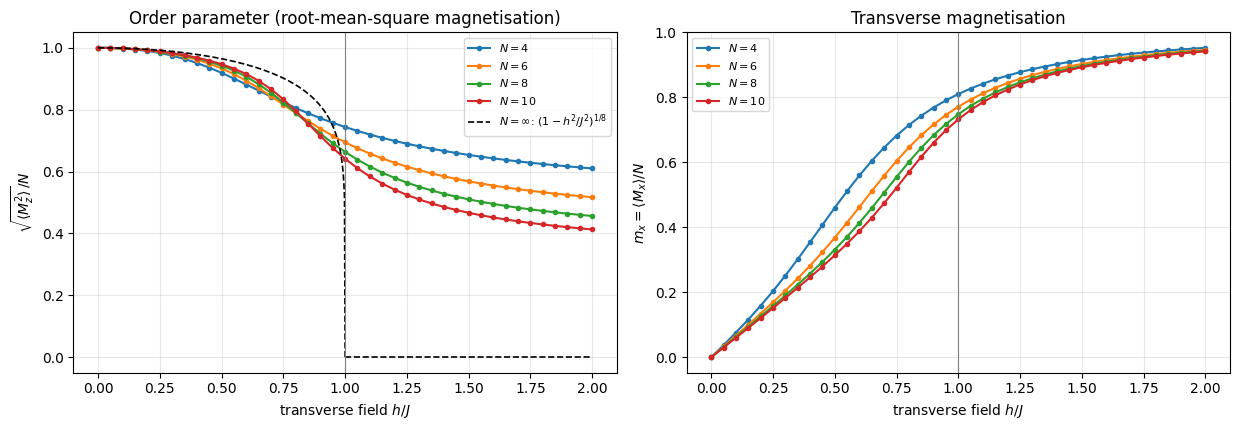

N =  4:  sqrt(m_z^2) at h/J=0.5: 0.9190   at h/J=1.5: 0.6539   (N=inf: 0.9647 and 0)
N =  6:  sqrt(m_z^2) at h/J=0.5: 0.9335   at h/J=1.5: 0.5685   (N=inf: 0.9647 and 0)
N =  8:  sqrt(m_z^2) at h/J=0.5: 0.9423   at h/J=1.5: 0.5103   (N=inf: 0.9647 and 0)
N = 10:  sqrt(m_z^2) at h/J=0.5: 0.9470   at h/J=1.5: 0.4668   (N=inf: 0.9647 and 0)


In [23]:
# ==============================================================================
# FIGURE: order parameter and transverse magnetisation of the TFIM ground state
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for c, N in enumerate(SWEEP_SIZES):
    _, m_x, m_z2 = sweep[N]
    axes[0].plot(h_over_J, np.sqrt(np.asarray(m_z2)), "o-", ms=3, color=f"C{c}", label=rf"$N={N}$")
    axes[1].plot(h_over_J, np.asarray(m_x), "o-", ms=3, color=f"C{c}", label=rf"$N={N}$")
h_fm = np.linspace(0, 1, 400)
axes[0].plot(h_fm, (1 - h_fm ** 2) ** 0.125, "k--", lw=1.2, label=r"$N=\infty$: $(1-h^2/J^2)^{1/8}$")
axes[0].plot([1, 2], [0, 0], "k--", lw=1.2)
axes[0].set_ylabel(r"$\sqrt{\langle M_z^2\rangle}/N$"); axes[0].set_title("Order parameter (root-mean-square magnetisation)")
axes[1].set_ylabel(r"$m_x=\langle M_x\rangle/N$"); axes[1].set_title("Transverse magnetisation")
for ax in axes:
    ax.axvline(1.0, color="0.5", lw=0.8); ax.set_xlabel(r"transverse field $h/J$"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

k05, k15 = (int(np.argmin(np.abs(h_over_J - hv))) for hv in (0.5, 1.5))
for N in SWEEP_SIZES:
    print(f"N = {N:2d}:  sqrt(m_z^2) at h/J=0.5: {float(jnp.sqrt(sweep[N][2][k05])):.4f}   at h/J=1.5: {float(jnp.sqrt(sweep[N][2][k15])):.4f}"
          f"   (N=inf: {(1 - 0.25) ** 0.125:.4f} and 0)")

*Left:* for $h<J$ the root-mean-square magnetisation is large and depends only weakly on $N$; it lies
somewhat below the infinite-chain curve (the spins at the open ends have only one neighbour and are less
ordered) and moves towards it as $N$ grows, see the printed values at $h/J=0.5$. For $h>J$ it keeps
decreasing with $N$ (asymptotically as $1/\sqrt N$; compare the printed values at $h/J=1.5$). The curves for
different $N$ cross and fan out on the way to $h=J$ and become steeper with increasing $N$ — the finite-size
rounding of the singular infinite-chain curve (dashed). Locating a critical point from such data is the art of
*finite-size scaling*. *Right:* $m_x$ grows linearly for small fields (second-order perturbation theory
around $|{\Uparrow}\rangle$, where each flipped spin in the bulk costs $4J$, gives $m_x\to h/2J$ for
$N\to\infty$; the open chains lie above that slope because a flip at either end costs only $2J$), bends
over around $h=J$ and saturates towards 1. Unlike $m_z$ it stays continuous through the transition even for
$N\to\infty$; what diverges there is its **slope**
$\mathrm{d}m_x/\mathrm{d}h = -\mathrm{d}^2e_0/\mathrm{d}h^2$, the second derivative of the ground-state
energy per site, and it diverges only logarithmically,
$\mathrm{d}m_x/\mathrm{d}h\simeq-\frac{1}{\pi J}\ln\lvert h/J-1\rvert$.
A logarithm is a very weak singularity: it is invisible in the finite-$N$
curves of the figure, which is why the transverse magnetisation is a poor place to look for the transition
and the order parameter of the left panel is the right one.

### 7.5 Ground-state correlations

The most detailed view of a ground state is given by its **correlation functions**, here

$$ C(r) = \langle Z_0Z_r\rangle . $$

We use a *periodic* chain, so that all sites are equivalent and $C$ depends only on the distance $r$ (at most
$N/2$ on a ring). The expected behaviour in the three regimes is:

* **ferromagnet** $h<J$: long-range order, $C(r)\to m_z^2=(1-h^2/J^2)^{1/4}>0$ for $r\to\infty$;
* **critical point** $h=J$: power-law decay $C(r)\sim r^{-1/4}$ — no length scale;
* **paramagnet** $h>J$: exponential decay $C(r)\sim e^{-r/\xi}$ with a finite correlation length $\xi$.

**From formula to code.** $Z_iZ_j$ is diagonal with entries $z_i(s)z_j(s)$, $z=\pm1$. With the sign table
`zt` of shape $(2^N,N)$ and the probabilities $p_s=|\psi_s|^2$, the full correlation matrix
$C_{ij}=\sum_sp_s\,z_i(s)z_j(s)$ is one matrix product, `(p[:, None] * zt).T @ zt`. We validate it against the
dense-operator expression $\langle\psi|Z_iZ_j|\psi\rangle$.

In [24]:
# ==============================================================================
# STEP 17: <Z_i Z_j> in the TFIM ground state (periodic chain)
# ==============================================================================
# ---- PARAMETERS ------------------------------------------------------------------------------------
N_CORR = 12                                     # ring length for the correlation functions (4096 x 4096 matrices)
CORR_FIELDS = (0.5, 1.0, 1.5)                   # ferromagnet, critical point, paramagnet
# ---------------------------------------------------------------------------------------------------


def zz_correlation_matrix(psi):
    """C_ij = <psi| Z_i Z_j |psi> for all pairs (i, j), from the probabilities |psi_s|^2.

    MATH   Z_i Z_j is diagonal:  C_ij = sum_s p_s z_i(s) z_j(s),   z_q(s) = 1 - 2 s_q = +-1
    IMPLEMENTATION   zt = sign table (2^N, N);  C = (p[:, None] * zt)^T @ zt   -- no 2^N x 2^N matrix.
    COST   O(N^2 2^N), versus O(4^N) per pair with dense operators.
    """
    N = int(np.log2(psi.shape[0]))
    zt = (1 - 2 * bits_table(N)).astype(RDTYPE)
    p = jnp.abs(psi) ** 2
    return (p[:, None] * zt).T @ zt


def ground_state(H):
    """Lowest eigenpair (E_0, |phi_0>) of a dense Hermitian matrix by full diagonalisation."""
    E, V = jnp.linalg.eigh(H)
    return E[0], V[:, 0]


corr_tfim = {}
for h in CORR_FIELDS:
    E0, gs = ground_state(as_real(tfim_dense(N_CORR, 1.0, h, periodic=True)))
    corr_tfim[h] = np.asarray(zz_correlation_matrix(gs))[0, : N_CORR // 2 + 1]      # C(r) = C_{0,r}, r = 0..N/2
    print(f"h/J = {h}: E0/N = {float(E0) / N_CORR:+.6f}   C(r) =", np.round(corr_tfim[h], 4))

print("Checkpoint: correlations")
r = 3
checkpoint("sign-table formula == <psi|Z_0 Z_3|psi> with the dense operator",
           abs(corr_tfim[CORR_FIELDS[-1]][r] - float(expval(gs.astype(CDTYPE), two_site_operator(Z, 0, Z, r, N_CORR)))))
checkpoint("ground-state energy == Eq. (5)", abs(float(E0) - tfim_ring_energy_exact(N_CORR, 1.0, CORR_FIELDS[-1])) / abs(float(E0)))

h/J = 0.5: E0/N = -1.063547   C(r) = [1.     0.9342 0.931  0.9306 0.9306 0.9305 0.9305]


h/J = 1.0: E0/N = -1.276883   C(r) = [1.     0.6384 0.5466 0.5023 0.4778 0.465  0.461 ]


h/J = 1.5: E0/N = -1.672052   C(r) = [1.     0.3574 0.1854 0.1078 0.0688 0.0501 0.0445]
Checkpoint: correlations


  [ok] sign-table formula == <psi|Z_0 Z_3|psi> with the dense operator error = 8.33e-17
  [ok] ground-state energy == Eq. (5)                             error = 0.00e+00


### 7.6 The Heisenberg antiferromagnet

For comparison we diagonalise the antiferromagnetic Heisenberg ring, $H=J\sum_j\boldsymbol\sigma_j\cdot\boldsymbol\sigma_{j+1}$
with $J=1$, for even $N$ up to 12. Three exact statements are known for its ground state:

* it is a **total-spin singlet**, $\mathbf S_{\rm tot}^2|\phi_0\rangle=0$ (theorem of Lieb and Mattis, 1962),
  in particular $M_z|\phi_0\rangle=0$ — a many-spin generalisation of the two-spin singlet of Section 3.4;
* its energy per site converges to the Bethe-ansatz value $1-4\ln2=-1.772589\ldots$ (Hulthén 1938);
* its correlations are antiferromagnetic, $C(r)\propto(-1)^r$, and decay as a power law, $\sim(-1)^r/r$ (up
  to logarithmic corrections): in one dimension quantum fluctuations destroy the classical Néel order
  $\uparrow\downarrow\uparrow\downarrow$, leaving a *critical* state.

The total spin is computed without any matrix–matrix product:
$\langle\mathbf S_{\rm tot}^2\rangle=\frac14\sum_\alpha\langle M_\alpha^2\rangle=\frac14\sum_\alpha\lVert M_\alpha|\phi_0\rangle\rVert^2$.

In [25]:
# ==============================================================================
# STEP 18: Heisenberg ring -- energy per site, total spin, correlations
# ==============================================================================
# ---- PARAMETERS ------------------------------------------------------------------------------------
HEIS_SIZES = (4, 6, 8, 10, 12)                  # even ring lengths (N = 12 takes a while: 4096 x 4096 again)
# ---------------------------------------------------------------------------------------------------
E_BETHE = 1 - 4 * np.log(2)                     # Bethe-ansatz energy per site, Pauli convention, J = 1

print("   N |   E0/N      | E0/N - Bethe |  <S_tot^2>")
heis_energy = {}
for N in HEIS_SIZES:
    E0, gs = ground_state(as_real(xxz_dense(N, J=1.0, Delta=1.0, periodic=True)))
    heis_energy[N] = float(E0) / N
    gs_c = gs.astype(CDTYPE)
    S2 = 0.25 * sum(jnp.linalg.norm(total_magnetisation(P, N) @ gs_c) ** 2 for P in (X, Y, Z))
    print(f"  {N:2d} | {heis_energy[N]:+.8f} | {heis_energy[N] - E_BETHE:+.6f}    | {float(S2):.2e}")
corr_heis = np.asarray(zz_correlation_matrix(gs))[0, : N // 2 + 1]                   # largest ring
N_HEIS = N
print(f"N = {N_HEIS}: C(r) = <Z_0 Z_r> =", np.round(corr_heis, 4))

print("Checkpoint: Heisenberg ring")
checkpoint("ground state is a total-spin singlet, <S_tot^2> = 0", S2)
checkpoint("isotropy: <X_0 X_1> = <Z_0 Z_1>",
           abs(float(expval(gs_c, two_site_operator(X, 0, X, 1, N_HEIS))) - corr_heis[1]))
checkpoint("E0/N = 3 <Z_0 Z_1>   (energy from the correlation function)",
           abs(heis_energy[N_HEIS] - 3 * corr_heis[1]))

   N |   E0/N      | E0/N - Bethe |  <S_tot^2>


   4 | -2.00000000 | -0.227411    | 5.69e-32


   6 | -1.86851709 | -0.095928    | 6.10e-31


   8 | -1.82554670 | -0.052958    | 2.58e-30


  10 | -1.80617854 | -0.033590    | 4.69e-30


  12 | -1.79579697 | -0.023208    | 1.38e-29
N = 12: C(r) = <Z_0 Z_r> = [ 1.     -0.5986  0.2504 -0.2211  0.1611 -0.1632  0.1427]
Checkpoint: Heisenberg ring
  [ok] ground state is a total-spin singlet, <S_tot^2> = 0        error = 1.38e-29


  [ok] isotropy: <X_0 X_1> = <Z_0 Z_1>                            error = 2.22e-16
  [ok] E0/N = 3 <Z_0 Z_1>   (energy from the correlation function) error = 6.66e-16


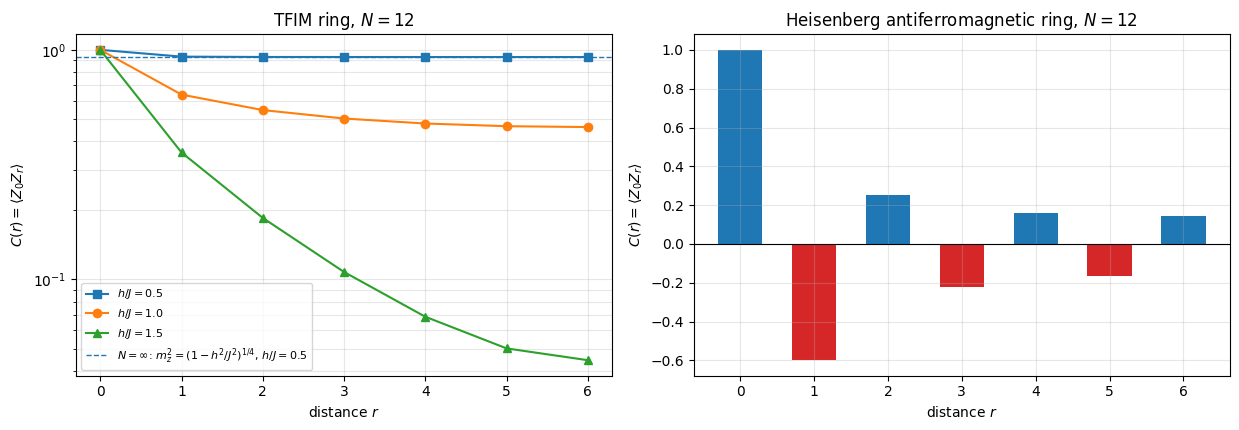

In [26]:
# ==============================================================================
# FIGURE: ground-state correlations of the TFIM and of the Heisenberg chain
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
r_tfim = np.arange(N_CORR // 2 + 1)
for c, (h, mk) in enumerate(zip(CORR_FIELDS, ("s", "o", "^"))):
    ax.semilogy(r_tfim, corr_tfim[h], mk + "-", color=f"C{c}", label=rf"$h/J={h}$")
ax.axhline((1 - CORR_FIELDS[0] ** 2) ** 0.25, color="C0", ls="--", lw=1, label=rf"$N=\infty$: $m_z^2=(1-h^2/J^2)^{{1/4}}$, $h/J={CORR_FIELDS[0]}$")
ax.set_xlabel(r"distance $r$"); ax.set_ylabel(r"$C(r)=\langle Z_0Z_r\rangle$")
ax.set_title(rf"TFIM ring, $N={N_CORR}$"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
ax = axes[1]
r_heis = np.arange(N_HEIS // 2 + 1)
ax.bar(r_heis, corr_heis, color=["C3" if v < 0 else "C0" for v in corr_heis], width=0.6)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel(r"distance $r$"); ax.set_ylabel(r"$C(r)=\langle Z_0Z_r\rangle$")
ax.set_title(rf"Heisenberg antiferromagnetic ring, $N={N_HEIS}$"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**TFIM (left, logarithmic scale).** In the ferromagnet ($h/J=0.5$) the correlations level off at a constant
close to the infinite-chain value $m_z^2=(1-h^2/J^2)^{1/4}\approx0.93$ (dashed): knowing the spin at site 0
tells you the spin at the opposite side of the ring. This is how long-range order shows up in a state with
$\langle Z_j\rangle=0$. In the paramagnet ($h/J=1.5$) the correlations fall on an almost straight line in
the semi-logarithmic plot — exponential decay $C(r)\sim e^{-r/\xi}$ over a couple of lattice spacings. The
exact infinite-chain correlation length is $\xi=1/\ln(h/J)=2.47$ sites at $h/J=1.5$; the successive ratios
of the printed $C(r)$ give the smaller effective values $1.5,\,1.8,\,2.2$, because the asymptotic form
carries a power-law prefactor in front of the exponential and $r\le6$ is not yet asymptotic. (The curve
flattens at the largest $r$ because of the periodic image: on a ring the two spins are connected both
ways round, so $C(r)=C(N-r)$ and the curve must have zero slope at $r=N/2$.) At
the critical point the decay is slow and curved on this scale, consistent with the power law
$C(r)\sim r^{-1/4}$; a ring of twelve sites is too short to read that exponent off directly, because the
periodic-image flattening sets in after two or three sites. Exercise 5 extracts the same exponent from a
quantity that uses the whole chain instead of one pair of sites: summing $C(r)\sim r^{-1/4}$ over the
$N^2$ pairs gives $\langle M_z^2\rangle/N^2\sim N^{-1/4}$, which is much better behaved in $N$.

**Heisenberg ring (right).** The sign alternates with distance — antiferromagnetic correlations — and the
magnitude decays slowly. The table confirms the theory: the ground state is a total-spin singlet to
numerical precision, the correlations are isotropic, and $E_0/N$ approaches the Bethe-ansatz value from
below, with a finite-size correction that shrinks roughly as $1/N^2$ (compare the differences for
$N=6$ and $N=12$). The last checkpoint is a useful identity: since all bonds and all three spin components
are equivalent, the energy is fixed by a single correlator, $E_0/N=3J\,C(1)$.

## 8. The exponential wall

### 8.1 Measured run times

We now look at the stopwatch data recorded in Section 7.3 while the chain length went from $N=2$ to $N=12$.

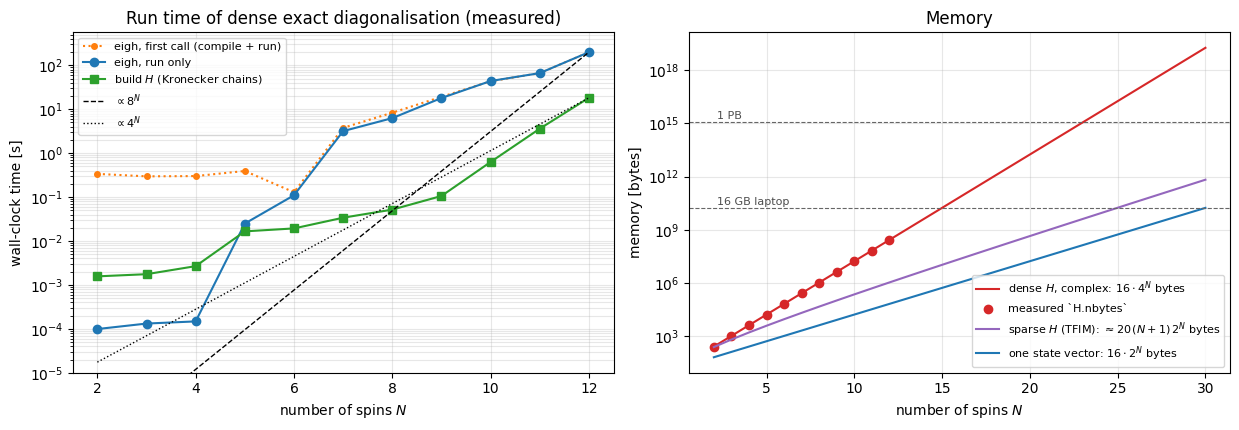

eigh: N=11 -> 66.66 s,  N=12 -> 199.90 s   (one more spin: x3.0)
extrapolation with the asymptotic factor 8 per spin, starting from the largest measured size:
   N = 14:   1.28e+04 s =       3.55 h =   0.000406 years      dense H:     4.0 GB
   N = 16:   8.19e+05 s =        227 h =      0.026 years      dense H:    64.0 GB
   N = 20:   3.35e+09 s =   9.32e+05 h =        106 years      dense H:    16.0 TB
   N = 30:    3.6e+18 s =      1e+15 h =   1.14e+11 years      dense H:    16.0 EB


In [27]:
# ==============================================================================
# FIGURE: measured cost of the dense approach versus N
# ==============================================================================
Ns, t_build, t_first, t_run, nbytes = wall[:, 0], wall[:, 2], wall[:, 3], wall[:, 4], wall[:, 5]
t_best = np.where(np.isnan(t_run), t_first, t_run)             # run time without compilation where available

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
ax.semilogy(Ns, t_first, "o:", color="C1", ms=4, label="eigh, first call (compile + run)")
ax.semilogy(Ns, t_best, "o-", color="C0", label="eigh, run only")
ax.semilogy(Ns, t_build, "s-", color="C2", label="build $H$ (Kronecker chains)")
ax.semilogy(Ns, t_best[-1] * 8.0 ** (Ns - Ns[-1]), "k--", lw=1, label=r"$\propto 8^N$")
ax.semilogy(Ns, t_build[-1] * 4.0 ** (Ns - Ns[-1]), "k:", lw=1, label=r"$\propto 4^N$")
ax.set_xlabel(r"number of spins $N$"); ax.set_ylabel("wall-clock time [s]"); ax.set_ylim(bottom=1e-5)
ax.set_title("Run time of dense exact diagonalisation (measured)"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
ax = axes[1]
N_ext = np.arange(2, 31)
ax.semilogy(N_ext, BYTES * 4.0 ** N_ext, "-", color="C3", label=rf"dense $H$, complex: ${BYTES}\cdot4^N$ bytes")
ax.semilogy(Ns, nbytes, "o", color="C3", label="measured `H.nbytes`")
ax.semilogy(N_ext, (BYTES + IDX_BYTES) * (N_ext + 1) * 2.0 ** N_ext, "-", color="C4",
            label=rf"sparse $H$ (TFIM): $\approx{BYTES + IDX_BYTES}\,(N+1)\,2^N$ bytes")
ax.semilogy(N_ext, BYTES * 2.0 ** N_ext, "-", color="C0", label=rf"one state vector: ${BYTES}\cdot2^N$ bytes")
for val, lab in ((16 * 2.0 ** 30, "16 GB laptop"), (2.0 ** 50, "1 PB")):
    ax.axhline(val, color="0.4", lw=0.8, ls="--"); ax.text(2.2, val * 1.5, lab, fontsize=8, color="0.3")
ax.set_xlabel(r"number of spins $N$"); ax.set_ylabel("memory [bytes]")
ax.set_title("Memory"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

ratio = t_best[-1] / t_best[-2]
print(f"eigh: N={int(Ns[-2])} -> {t_best[-2]:.2f} s,  N={int(Ns[-1])} -> {t_best[-1]:.2f} s   (one more spin: x{ratio:.1f})")
print("extrapolation with the asymptotic factor 8 per spin, starting from the largest measured size:")
for N_target in (14, 16, 20, 30):
    t = t_best[-1] * 8.0 ** (N_target - Ns[-1])
    print(f"   N = {N_target}: {t:10.3g} s = {t / 3600:10.3g} h = {t / 3.15e7:10.3g} years      dense H: {human(BYTES * 4.0 ** N_target)}")

**Reading the figure.** For small $N$ the run time is flat: the matrices are tiny and we only measure fixed
overheads (Python, dispatch, and — orange — compilation on the first call). From $N\approx8$ on the
asymptotic scaling takes over and the measured points turn upwards, bending towards the dashed $8^N$ line:
**every additional spin must eventually multiply the diagonalisation time by $2^3=8$**, while the memory
grows by exactly $4$ per spin. The ratio printed above is the *measured* one for a single step, $N=11\to12$,
and it is not a precision measurement of the exponent: consecutive runs of this very cell on one and the
same machine scatter it over the whole range from about $4$ to about $20$, depending on what else the
machine is doing. Three reasons. At these matrix sizes a multi-core CPU is still
ramping up its parallel efficiency (a $4096\times4096$ eigendecomposition keeps the cores busier than a
$2048\times2048$ one); the last two rows are first-call timings and still contain compilation; and a machine
shared with other jobs adds scatter of a factor of two in either direction. Only the slope over *several*
spins is meaningful. The absolute numbers depend on your machine and on how busy it is; the trend does
not. The extrapolation printed above is the point of the exercise: whatever the time for
$N=12$ is on your computer, $N=16$ takes $8^4=4096$ times longer and needs 64 GB just to store $H$; for
$N=20$ the matrix alone needs 16 TB. Buying a computer that is a thousand times faster and bigger gains
$\log_8 1000\approx3$ spins in time, and 5 spins in memory. This is the **exponential wall**.

### 8.2 Where the memory goes

The three objects that a many-body calculation may have to store differ enormously in size:

In [28]:
# ==============================================================================
# TABLE: memory of a state vector, a sparse H and a dense H (CDTYPE: 16 bytes per number in double precision)
# ==============================================================================
nnz_measured = {int(row[0]): int(row[6]) for row in wall}
print(f"complex number = {BYTES} bytes ({np.dtype(CDTYPE).name}), sparse column index = {IDX_BYTES} bytes\n")
print("   N |   dimension 2^N   | state vector | sparse H (TFIM) |   dense H    | non-zeros of H: measured vs (N+1) 2^N")
for N in (4, 8, 12, 16, 20, 24, 30, 40):
    d = 2 ** N
    nnz = (N + 1) * d                                           # N spin-flip entries + 1 diagonal entry per row
    note = f"{nnz_measured[N]} vs {nnz}" if N in nnz_measured else ""
    print(f"  {N:2d} | {d:17,d} | {human(BYTES * d)}   | {human((BYTES + IDX_BYTES) * nnz + IDX_BYTES * d)}      "
          f"| {human(BYTES * d * d)}   | {note}")
# off-diagonal part: exactly N entries per row; the diagonal entry (Ising energy) can vanish only for odd N
assert all(nnz_measured[N] <= (N + 1) * 2 ** N for N in nnz_measured)
assert all(nnz_measured[N] == (N + 1) * 2 ** N for N in nnz_measured if N % 2 == 0 and N > 2)

complex number = 16 bytes (complex128), sparse column index = 4 bytes

   N |   dimension 2^N   | state vector | sparse H (TFIM) |   dense H    | non-zeros of H: measured vs (N+1) 2^N
   4 |                16 |   256.0 B    |     1.6 kB      |     4.0 kB   | 80 vs 80
   8 |               256 |     4.0 kB   |    46.0 kB      |     1.0 MB   | 2304 vs 2304
  12 |             4,096 |    64.0 kB   |     1.0 MB      |   256.0 MB   | 53248 vs 53248
  16 |            65,536 |     1.0 MB   |    21.5 MB      |    64.0 GB   | 
  20 |         1,048,576 |    16.0 MB   |   424.0 MB      |    16.0 TB   | 
  24 |        16,777,216 |   256.0 MB   |     7.9 GB      |     4.0 PB   | 
  30 |     1,073,741,824 |    16.0 GB   |   624.0 GB      |    16.0 EB   | 
  40 | 1,099,511,627,776 |    16.0 TB   |   824.0 TB      |    16.0 YB   | 


Three very different growth laws (the numbers quoted below are for the default double precision, where a
complex number takes 16 bytes; with `PRECISION = "single"` every entry of the table is halved):

* **dense $H$**: $16\cdot4^N$ bytes. 256 MB at $N=12$, a terabyte-scale object at $N=18$–$20$, more than all
  the storage on Earth long before $N=40$. And almost all of it is zeros: we *measured* (last column of the
  table in Section 7.3) that the TFIM matrix has at most $(N+1)\,2^N$ non-zero entries out of $4^N$ — $N$
  spin-flip partners per row (recall the figure in Section 4.2) plus one diagonal entry, the classical Ising
  energy. (For even $N$ the count is exactly $(N+1)2^N$; for odd $N$ it is slightly smaller, because the
  Ising energy of an open chain with an even number of bonds vanishes for some configurations.)
* **sparse $H$**: storing only the non-zeros (value + column index, about 20 bytes each for a complex
  matrix) costs $\approx20(N+1)2^N$ bytes: $N=20$ fits in half a gigabyte, $N=30$ needs more than 600 GB.
  A *real* matrix — which is what all Hamiltonians of this notebook are — halves the 16 bytes of the value
  and gets away with about 12 bytes per entry, as the measurement in Section 8.3 confirms.
* **one state vector**: $16\cdot2^N$ bytes — 16 MB at $N=20$, 16 GB at $N=30$. This is the irreducible cost of
  storing a generic quantum state exactly. $N\approx45$–$50$ is the limit of the largest supercomputers.

### 8.3 The traditional remedy: sparse matrices and iterative eigensolvers

The classical answer to the wall has two ingredients. (i) Store $H$ in a **sparse format**. (ii) Do not ask
for all $2^N$ eigenpairs; ask for the ground state and a few excited states, which **iterative (Krylov)
methods** such as the Lanczos algorithm deliver using nothing but matrix–vector products $H|\psi\rangle$, each
costing $O(N2^N)$ instead of $O(8^N)$. (We derive Lanczos from scratch in
[notebook 11 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb).)

As a glimpse, the next cell uses SciPy's sparse matrices and its Lanczos-type solver `eigsh` as a black box
to obtain the critical gap for $N=16$ — a size for which the dense matrix would need 64 GB. The construction
is *identical* to `build_hamiltonian_dense`; only `jnp.kron` is replaced by `scipy.sparse.kron`.

In [29]:
# ==============================================================================
# STEP 19 (glimpse): sparse TFIM at N = 16 with scipy.sparse -- same Kronecker chains, sparse storage
# ==============================================================================
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh

N_SPARSE = 16                                   # a dense complex H would need 16 * 4^16 bytes = 64 GB


def kron_chain_sparse(ops):
    """Kronecker chain of small matrices, kept in compressed sparse row (CSR) format throughout."""
    out = sp.identity(1, format="csr")
    for op in ops:
        out = sp.kron(out, op, format="csr")
    return out


def tfim_sparse(N, J=1.0, h=1.0):
    """Open TFIM chain as a scipy.sparse CSR matrix (real)."""
    I_, X_, Z_ = (sp.csr_matrix(np.asarray(M).real) for M in (I2, X, Z))
    H = sp.csr_matrix((2 ** N, 2 ** N))
    for j in range(N - 1):
        ops = [I_] * N; ops[j], ops[j + 1] = Z_, Z_
        H = H - J * kron_chain_sparse(ops)
    for j in range(N):
        ops = [I_] * N; ops[j] = X_
        H = H - h * kron_chain_sparse(ops)
    return H


# checkpoint on a small system first: sparse == dense
checkpoint("sparse TFIM (N=6) == dense TFIM", np.abs(tfim_sparse(6, 1.0, 0.7).toarray() - np.asarray(tfim_dense(6, 1.0, 0.7)).real).max())

t0 = time.perf_counter()
H_sp = tfim_sparse(N_SPARSE, 1.0, 1.0)
t_build_sp = time.perf_counter() - t0
t0 = time.perf_counter()
E_sp = np.sort(eigsh(H_sp, k=2, which="SA", return_eigenvectors=False))          # two lowest ("smallest algebraic")
t_eig_sp = time.perf_counter() - t0
mem_sp = H_sp.data.nbytes + H_sp.indices.nbytes + H_sp.indptr.nbytes
print(f"N = {N_SPARSE}: dimension {2 ** N_SPARSE},  non-zeros {H_sp.nnz} = (N+1) 2^N = {(N_SPARSE + 1) * 2 ** N_SPARSE}")
print(f"         sparse H: {human(mem_sp)}   vs dense: {human(BYTES * 4 ** N_SPARSE)}")
print(f"         build {t_build_sp:.2f} s,  two lowest eigenvalues {t_eig_sp:.2f} s")
gap_sp, gap_exact = E_sp[1] - E_sp[0], 4 * np.sin(np.pi / (2 * (2 * N_SPARSE + 1)))
print(f"         critical gap = {gap_sp:.10f}   Eq. (7): {gap_exact:.10f}")
checkpoint(f"sparse Lanczos gap at N={N_SPARSE} == Eq. (7)", abs(gap_sp - gap_exact), tol=1e-8)

  [ok] sparse TFIM (N=6) == dense TFIM                            error = 0.00e+00


N = 16: dimension 65536,  non-zeros 1114112 = (N+1) 2^N = 1114112
         sparse H:    13.0 MB   vs dense:    64.0 GB
         build 0.38 s,  two lowest eigenvalues 46.24 s
         critical gap = 0.1903276633   Eq. (7): 0.1903276633
  [ok] sparse Lanczos gap at N=16 == Eq. (7)                      error = 6.74e-14


The sparse matrix with its $(N+1)2^N\approx1.1$ million non-zeros takes 13 MB (real entries: 8 bytes per value
plus 4 bytes per column index) instead of 64 GB, and the two lowest eigenvalues — in agreement with the exact
formula (7) to better than $10^{-8}$ — are obtained in the time printed above. Compare that with
the *hours* that the $8^N$ extrapolation of Section 8.1 predicts for a dense diagonalisation at $N=16$ — a run
that could not be started in the first place, for want of 64 GB of memory. Sparse exact diagonalisation
(usually combined with the symmetry sectors of Section 6.2) is a mature technique and the workhorse of
computational quantum magnetism; record calculations reach $N\approx50$ spins.

### 8.4 The remedy of this course: never build the matrix at all

A sparse matrix is still a *stored* matrix: a list of $(N+1)2^N$ numbers and indices that encodes, entry by
entry, a rule we already know in closed form — "$X_j$ flips bit $j$", "$Z_iZ_j$ multiplies by $\pm1$". The
approach of this course goes one step further. We keep **only the state**, not as a vector of length $2^N$
but as an array with $N$ axes of length 2 (one axis per spin, `psi.reshape((2,)*N)`), and we apply each local
term of $H$ directly to the axes it acts on, as a tiny $2\times2$ or $4\times4$ contraction. The operator
$1\otimes\cdots\otimes\sigma\otimes\cdots\otimes1$ is never formed — neither densely nor sparsely. The cost
of $H|\psi\rangle$ is $O(N2^N)$ time and $O(2^N)$ memory, the code is a few lines, and it runs unchanged
(and fast) on a GPU under `jax.jit`. That is the subject of
[notebook 05 — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb), the core lecture of Chapter 3. Before
that, [notebook 04](04_time_evolution_the_textbook_way.ipynb) stays with the dense matrices of this notebook
for one more round and makes the spins *move*: time evolution, the textbook way.

The functions `site_operator` and `build_hamiltonian_dense` will remain with us for the whole course in a new
role: as the slow-but-obviously-correct **reference** against which every fast method is validated on small
systems.

## 9. Key takeaways

* The Hilbert space of $N$ spins-1/2 is the tensor product $(\mathbb C^2)^{\otimes N}$ of dimension $2^N$.
  Basis states are bit strings; with our convention **spin 0 is the left-most Kronecker factor and the most
  significant bit** of the flat index, $i=\sum_qs_q2^{N-1-q}$.
* Most states in this space are **entangled**: they cannot be described spin by spin. In the singlet every
  local expectation value vanishes while the correlations are perfect.
* A site operator is a Kronecker chain $1\otimes\cdots\otimes\sigma\otimes\cdots\otimes1$; a Hamiltonian is a
  sum of such chains. `site_operator` and `build_hamiltonian_dense` are literal transcriptions of the
  formulas.
* **Exact diagonalisation** = build $H$, call `eigh`, check the result (residual, orthonormality, known
  limits, exact solutions). It gives *everything* — all energies and eigenstates to machine precision.
* Physics of the TFIM seen in chains of 4–12 spins: a quasi-degenerate ground-state doublet and domain-wall
  excitations for $h<J$, a spin-flip gap $2(h-J)$ for $h>J$, and a gap closing as $\pi J/N$ at the quantum
  critical point $h=J$; long-range, power-law and exponentially decaying correlations in the three regimes.
  The Heisenberg antiferromagnet has a singlet ground state with alternating, slowly decaying correlations.
* **Symmetries** ($M_z$ for XXZ, spin-flip parity for the TFIM) make $H$ block diagonal; they also force
  $\langle Z_j\rangle=0$ in finite TFIM chains, so order must be detected through $\langle M_z^2\rangle$ or
  correlations.
* The dense approach costs $O(4^N)$ memory and $O(8^N)$ time — we measured it. It ends at $N\approx14$ on a
  laptop. Sparse matrices with iterative solvers reach further, and the matrix-free tensor approach of this
  course needs only $O(2^N)$ memory.

## 10. Exercises

1. ★ **Bell states.** Build the four Bell states $(|00\rangle\pm|11\rangle)/\sqrt2$,
   $(|01\rangle\pm|10\rangle)/\sqrt2$ with `jnp.kron`. For each compute `concurrence_two_spins` and the three
   correlators $\langle X_0X_1\rangle,\langle Y_0Y_1\rangle,\langle Z_0Z_1\rangle$. Which combination of signs
   identifies each state? Which of them are eigenstates of the two-spin Heisenberg Hamiltonian of Section 3.5,
   and with which energy?
2. ★ **Conventions.** Without running code, predict the flat index of $|{\downarrow\uparrow\uparrow\downarrow\uparrow}\rangle$
   and the diagonal of $Z_1$ for $N=3$. Verify with `bits_to_index` and `site_operator`. Then build the wrong
   operator `kron_chain` with the list reversed and find a checkpoint of Section 4.2 that catches the error.
3. ★★ **Four spins on a ring (physics).** Write the Heisenberg ring of four spins as
   $H=J(\boldsymbol\sigma_0+\boldsymbol\sigma_2)\cdot(\boldsymbol\sigma_1+\boldsymbol\sigma_3)$ and use the
   total-spin trick of Section 3.5 three times (for $\mathbf S_{02}$, $\mathbf S_{13}$ and $\mathbf S_{\rm tot}$)
   to derive the full spectrum analytically, in particular $E_0=-8J$. Compare with `eigvalsh`, including the
   degeneracies.
4. ★★ **Longitudinal field.** Add a field $h_z\sum_jZ_j$ to the TFIM (`hz` argument). Show numerically that
   parity is no longer a symmetry, that $\langle Z_j\rangle\neq0$ in the ground state, and plot the two lowest
   levels versus $h_z\in[-0.2,0.2]$ at $h=0.5J$: the quasi-degenerate doublet splits linearly, with slope
   $\approx\pm N m_z$. This is how a tiny symmetry-breaking field selects one of the two ordered states.
5. ★★ **Finite-size scaling (physics).** At $h=J$ the theory of critical phenomena predicts
   $\langle M_z^2\rangle/N^2\sim N^{-1/4}$ for the TFIM. Extract the exponent from a log–log fit for the
   periodic chains $N=4,6,8,10,12$ and discuss the deviation from $1/4$. Repeat slightly off criticality
   ($h=0.9J$ and $h=1.1J$) and describe how the curves bend away from the power law.
6. ★★★ **Extend the code: symmetry sectors.** For the XXZ chain, select the basis states with $M_z=0$
   (`mz_diagonal(N) == 0`), extract the corresponding block `H[idx][:, idx]` and diagonalise only this block.
   Check that its lowest eigenvalue equals the ground-state energy of the full matrix for even $N$. Compare
   dimensions, memory and run time with the full diagonalisation for $N=12$. Then go further: build the block
   *directly*, without ever forming the full matrix, by looping over the bit strings of the sector — how far
   in $N$ can you go?
7. ★★★ **Extend the code: frustration and an exact ground state.** Generalise
   `build_hamiltonian_dense` to accept an arbitrary list of `bonds` with bond-dependent couplings, and build
   the $J_1$–$J_2$ Heisenberg ring $H=J_1\sum_j\boldsymbol\sigma_j\cdot\boldsymbol\sigma_{j+1}+J_2\sum_j\boldsymbol\sigma_j\cdot\boldsymbol\sigma_{j+2}$.
   At the Majumdar–Ghosh point $J_2=J_1/2$ the ground state is exactly known: a product of nearest-neighbour
   singlets, two-fold degenerate, with $E_0=-\frac32J_1N$ in Pauli convention. Verify the energy and the
   degeneracy for $N=8,10,12$, construct the dimer state with `jnp.kron` from the `singlet` of Section 3.4 and
   check that it is an eigenstate. What does $C(r)$ look like?
8. ★★ **The wall on your machine.** Re-run Section 7.3 with `PRECISION = "single"` in the configuration cell.
   How do run time and memory change? Which checkpoints become delicate, and why is the exponentially small
   doublet splitting $E_1-E_0$ at $h<J$ the first casualty of reduced precision?

## 11. References

*Textbooks and lecture notes*

* J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, 3rd ed. (Cambridge University Press, 2020),
  ISBN 978-1-108-47322-4, DOI 10.1017/9781108587280 — spin-1/2 and the Stern-Gerlach experiment (Ch. 1),
  tensor products of state spaces and addition of angular momenta (Ch. 3).
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press,
  2000) — tensor products, qubits, the Bloch sphere, entanglement.
* S. Sachdev, *Quantum Phase Transitions*, 2nd ed. (Cambridge University Press, 2011),
  ISBN 978-0-521-51468-2 — the transverse-field Ising model as the paradigm of quantum criticality; the
  chapter *The Ising chain in a transverse field*, pp. 135–170, derives everything we only quote here.
* A. W. Sandvik, *Computational studies of quantum spin systems*, AIP Conf. Proc. **1297**, 135–338 (2010),
  DOI 10.1063/1.3518900 — a very readable introduction to exact diagonalisation with symmetries.
* A. Weiße and H. Fehske, *Exact diagonalization techniques*, in *Computational Many-Particle Physics*,
  Lecture Notes in Physics **739**, 529–544 (Springer, 2008), DOI 10.1007/978-3-540-74686-7_18.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of
  Scientific Computing*, 3rd ed. (Cambridge University Press, 2007), ISBN 978-0-521-88068-8 — Ch. 11
  (*Eigensystems*): Householder reduction to tridiagonal form, the QL/QR and divide-and-conquer algorithms
  that run behind `eigh`, and the backward-error bounds quoted in Section 7.1; Ch. 2 for sparse storage.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes in Fortran 90: The
  Art of Parallel Scientific Computing*, Vol. 2 of *Fortran Numerical Recipes*, 2nd ed. (Cambridge
  University Press, 1996), ISBN 978-0-521-57439-6 — the whole-array style that `jnp`/`vmap` code inherits.

*Original papers*

* R. P. Feynman, *Simulating physics with computers*, Int. J. Theor. Phys. **21**, 467–488 (1982),
  DOI 10.1007/BF02650179 — the exponential cost of classical simulation and the proposal of Section 1.
* H. Bethe, *Zur Theorie der Metalle. I. Eigenwerte und Eigenfunktionen der linearen Atomkette*,
  Z. Phys. **71**, 205 (1931) — exact solution of the Heisenberg chain.
* L. Hulthén, *Über das Austauschproblem eines Kristalles*, Ark. Mat. Astron. Fys. **26A**, 1 (1938) —
  ground-state energy of the antiferromagnetic chain.
* E. Lieb, T. Schultz and D. Mattis, *Two soluble models of an antiferromagnetic chain*, Ann. Phys. **16**,
  407 (1961) — free-fermion solution of XY-type chains.
* E. Lieb and D. Mattis, *Ordering of energy levels of interacting spin systems*, J. Math. Phys. **3**, 749
  (1962) — the ground state of bipartite antiferromagnets is a singlet.
* P. Pfeuty, *The one-dimensional Ising model with a transverse field*, Ann. Phys. **57**, 79 (1970) — exact
  spectrum, magnetisation and correlations of the TFIM chain.
* C. K. Majumdar and D. K. Ghosh, *On next-nearest-neighbor interaction in linear chain. I*, J. Math. Phys.
  **10**, 1388 (1969) — the exactly solvable point of Exercise 7.

*Experiments and quantum simulators*

* R. Coldea *et al.*, *Quantum criticality in an Ising chain: experimental evidence for emergent E8
  symmetry*, Science **327**, 177–180 (2010), DOI 10.1126/science.1180085 — CoNb$_2$O$_6$ in a transverse
  field.
* A. Browaeys and T. Lahaye, *Many-body physics with individually controlled Rydberg atoms*, Nature Physics
  **16**, 132–142 (2020), DOI 10.1038/s41567-019-0733-z — the Rydberg Ising Hamiltonian of Section 5, with
  its detuning term and $1/r^6$ couplings.
* H. Bernien *et al.*, *Probing many-body dynamics on a 51-atom quantum simulator*, Nature **551**, 579–584
  (2017), DOI 10.1038/nature24622 — Rydberg-atom arrays.
* S. Ebadi *et al.*, *Quantum phases of matter on a 256-atom programmable quantum simulator*, Nature **595**,
  227–232 (2021), DOI 10.1038/s41586-021-03582-4 — the upper end of the "50–250 spins" of Section 1.
* J. Zhang *et al.*, *Observation of a many-body dynamical phase transition with a 53-qubit quantum
  simulator*, Nature **551**, 601–604 (2017), DOI 10.1038/nature24654 — trapped ions with long-range
  Ising couplings $J_{ij}\propto|i-j|^{-\alpha}$.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644) · [GitHub](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*.

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/